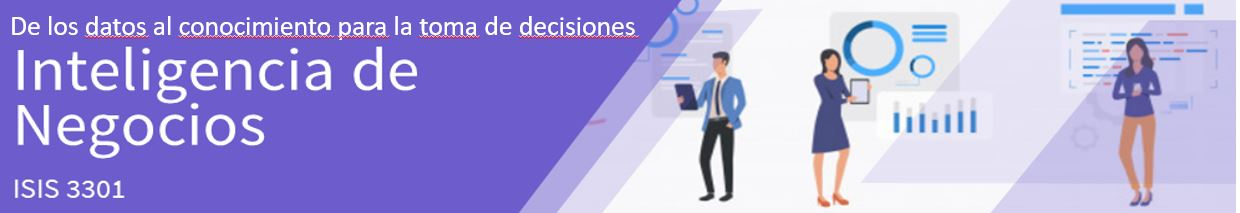

## Tarea de agrupación

El objetivo de este notebook es mostrar cómo resolver una tarea de **agrupación (clustering)** utilizando la librería **scikit-learn**.

En este laboratorio aplicamos algoritmos de agrupación no supervisada al caso de *SenecaféAlpes*, una empresa dedicada a la producción de café de alta calidad. Usando un conjunto de datos con atributos de los granos de café, el objetivo es identificar patrones que apoyen los procesos de **control de calidad** y **optimización de mercado**. Siguiendo la metodología **CRISP-ML**, el proyecto incluye una sección de **preparación de datos**, modelamiento con **K-Means**, **DBSCAN** y **_____**, además de validación cuantitativa y cualitativa. Finalmente, se presentan conclusiones y recomendaciones orientadas al negocio, útiles para la organización.



## Caso
SenecaféAlpes es una compañía dedicada a la producción, procesamiento y comercialización de café de alta calidad. Uno de sus principales retos consiste en garantizar la uniformidad y trazabilidad de sus granos, ya que la heterogeneidad en tamaño, forma y estructura puede afectar tanto los procesos de tostión como la percepción de calidad del consumidor final. Para enfrentar este desafío, la empresa implementó un sistema de visión por computadora que capturó imágenes de granos correspondientes a siete variedades registradas de café. Tras un proceso de segmentación y extracción de características, se construyó un conjunto de datos con 16 atributos para cada grano.

A partir de este insumo, SenecaféAlpes ha decidido emprender un proyecto de analítica de datos cuyo objetivo es la aplicación de técnicas de agrupación para identificar patrones morfológicos que permitan caracterizar las distintas variedades de café. La expectativa de la empresa es que los resultados de este estudio generen beneficios en tres dimensiones principales: (i) control de calidad, mediante la caracterización morfológica de los granos para estandarizar procesos de selección y clasificación; (ii) optimización del mercado, a partir de la comprensión de las agrupaciones naturales de las variedades y su aprovechamiento en el diseño de nuevas mezclas con valor agregado; (iii) innovación en trazabilidad, estableciendo las bases para sistemas automáticos de identificación que reduzcan la dependencia de evaluaciones manuales.
Para llevar a cabo este proyecto, la empresa nos ha contratado como científicos de datos, proporcionándonos no solo el conjunto de datos generado, sino también la documentación correspondiente a la descripción detallada de cada atributo (diccionario).

- [Datos de entrenamiento](Datos_SenecaféAlpes.csv)
- [Diccionario de datos](Diccionario_SenecaféAlpes.xlsx)


## 1. Carga de librerías necesarias para implementación

In [1]:
import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()  # for plot styling

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D # for 3D plots


## 2. Cargar los datos

In [2]:
# Se cargan los datos. 
df=pd.read_csv('data/Datos_SenecaféAlpes.csv', sep=';', encoding = "UTF-8")

## 3. Entendimiento de los datos 

### 3.1. Perfilamiento de datos

In [3]:
df.shape

(14291, 19)

In [4]:
df.head()

,ID,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,RelacionAspecto,Excentricidad,AreaConvexa,DiametroEquivalente,Medida,Solidez,Redondez,Compacidad,FactorForma1,FactorForma2,FactorForma3,FactorForma4,DefectoVisible,MétodoSecado
0,G006149,50836,923618.0,358.515147,181.388899,alargado,NaN,NaN,254.413847,0.804762,0.983840,0.748853,0.709632,0.007052,0.001103,0.503578,0.995321,Normal,Lavado
1,G007234,62764,1003767.0,409.207082,198.330199,Alargado,NaN,64158.0,282.689948,0.703995,0.978272,0.782807,0.690824,0.006520,0.000916,0.477237,0.984666,NaN,Natural
2,G007054,59965,994266.0,389.088529,197.967275,Alargado,0.860886,60910.0,276.314692,0.661581,0.984485,0.762259,0.710159,0.006489,0.001018,0.504326,0.991211,Normal,Natural
3,G006619,55035,917.6,379.346822,185.390577,Alargado,0.872446,55591.0,NaN,0.799695,0.989998,0.821376,0.697811,0.006893,0.001008,0.486941,0.996380,Normal,Lavado
4,G013353,39324,737773.0,262.520242,191.176858,Alargado,0.685326,39758.0,223.760747,0.775392,0.989084,0.907867,0.852356,0.006676,0.002174,0.726511,0.997630,Normal,Lavado


In [5]:
# Revisar las características de los datos: completitud y tipo de dato
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14291 entries, 0 to 14290
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   14291 non-null  object 
 1   Area                 14291 non-null  int64  
 2   Perimetro            13054 non-null  float64
 3   LongitudEjeMayor     13890 non-null  float64
 4   LongitudEjeMenor     14291 non-null  float64
 5   RelacionAspecto      13825 non-null  object 
 6   Excentricidad        13687 non-null  float64
 7   AreaConvexa          12868 non-null  float64
 8   DiametroEquivalente  12368 non-null  float64
 9   Medida               14291 non-null  float64
 10  Solidez              11985 non-null  float64
 11  Redondez             12228 non-null  float64
 12  Compacidad           13641 non-null  float64
 13  FactorForma1         13172 non-null  float64
 14  FactorForma2         13185 non-null  float64
 15  FactorForma3         13813 non-null 

In [6]:
# Resumen de los estadisticos de las variables numéricas
df.describe()

,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,Excentricidad,AreaConvexa,DiametroEquivalente,Medida,Solidez,Redondez,Compacidad,FactorForma1,FactorForma2,FactorForma3,FactorForma4
count,14291.000000,1.305400e+04,13890.000000,14291.000000,13687.000000,12868.000000,12368.000000,14291.000000,11985.000000,12228.000000,13641.000000,13172.000000,13185.000000,13813.000000,13132.000000
mean,53055.408999,7.729870e+05,319.985592,202.178613,0.749977,53575.397809,253.001741,0.749844,0.986774,0.873080,0.799242,0.006560,0.001712,0.643183,0.994292
std,29396.080372,3.266493e+05,86.378452,45.494541,0.099438,29566.387814,60.542330,0.050774,0.025947,0.063237,0.067643,0.001164,0.000601,0.100857,0.039081
min,-62716.000000,-1.012143e+06,-421.444657,-200.838672,-0.835004,-78423.000000,-448.402605,-0.798706,-0.989042,-0.896861,-0.843901,-0.007982,-0.002673,-0.683269,-0.998527
25%,36338.000000,6.768608e+05,253.319858,175.881052,0.715144,36720.000000,215.302463,0.718767,0.985597,0.832824,0.762127,0.005903,0.001151,0.581047,0.993663
50%,44660.000000,7.720345e+05,296.682345,192.437870,0.764392,45107.500000,238.579492,0.760232,0.988279,0.883353,0.800994,0.006645,0.001691,0.641648,0.996377
75%,61311.000000,9.554098e+05,376.548109,216.847844,0.810441,62109.250000,279.672481,0.786942,0.989991,0.916803,0.834405,0.007273,0.002169,0.696366,0.997889
max,254616.000000,1.921685e+06,738.860154,460.198497,0.911423,251082.000000,569.374358,0.866195,0.994378,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [7]:
# Separar variables numericas y categoricas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Valores Numericos: ", num_cols)
print("Valores Categoricos: ", cat_cols)

Valores Numericos:  ['Area', 'Perimetro', 'LongitudEjeMayor', 'LongitudEjeMenor', 'Excentricidad', 'AreaConvexa', 'DiametroEquivalente', 'Medida', 'Solidez', 'Redondez', 'Compacidad', 'FactorForma1', 'FactorForma2', 'FactorForma3', 'FactorForma4']
Valores Categoricos:  ['ID', 'RelacionAspecto', 'DefectoVisible', 'MétodoSecado']


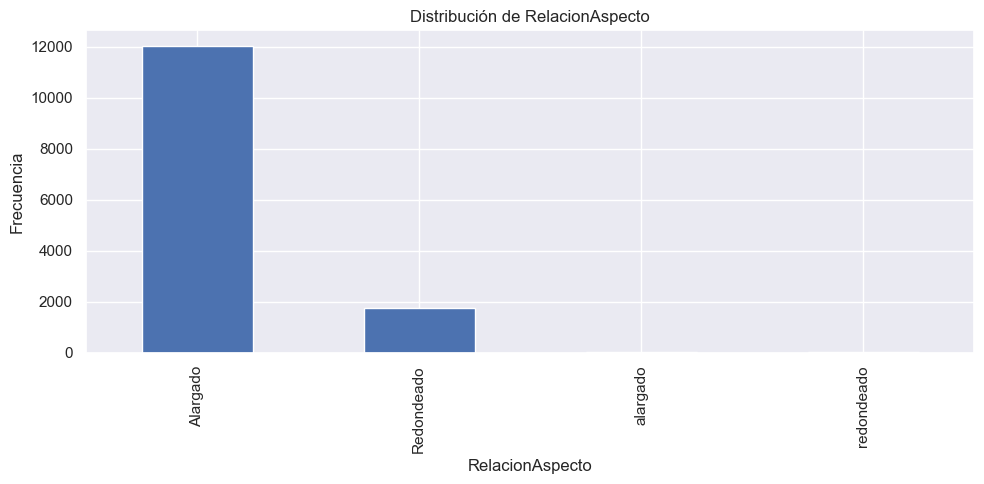

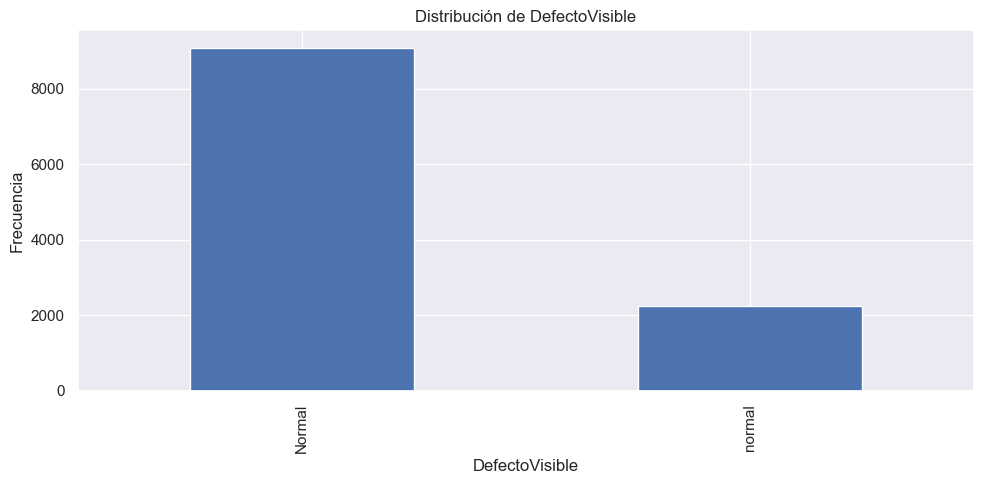

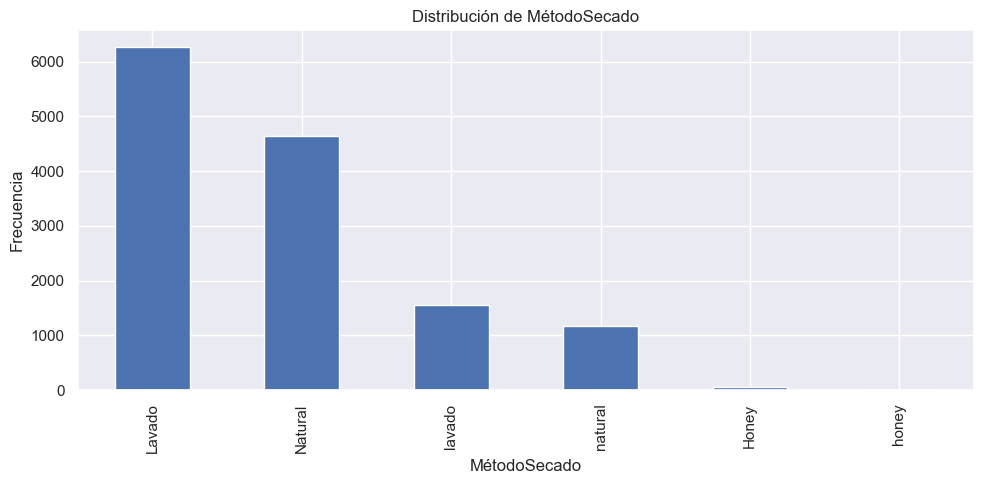

In [8]:
for col in cat_cols:
    if df[col].nunique() <= 20:
        plt.figure(figsize=(10, 5))
        df[col].value_counts().plot(kind="bar")
        plt.title(f"Distribución de {col}")
        plt.xlabel(col)
        plt.ylabel("Frecuencia")
        plt.tight_layout()
        plt.show()

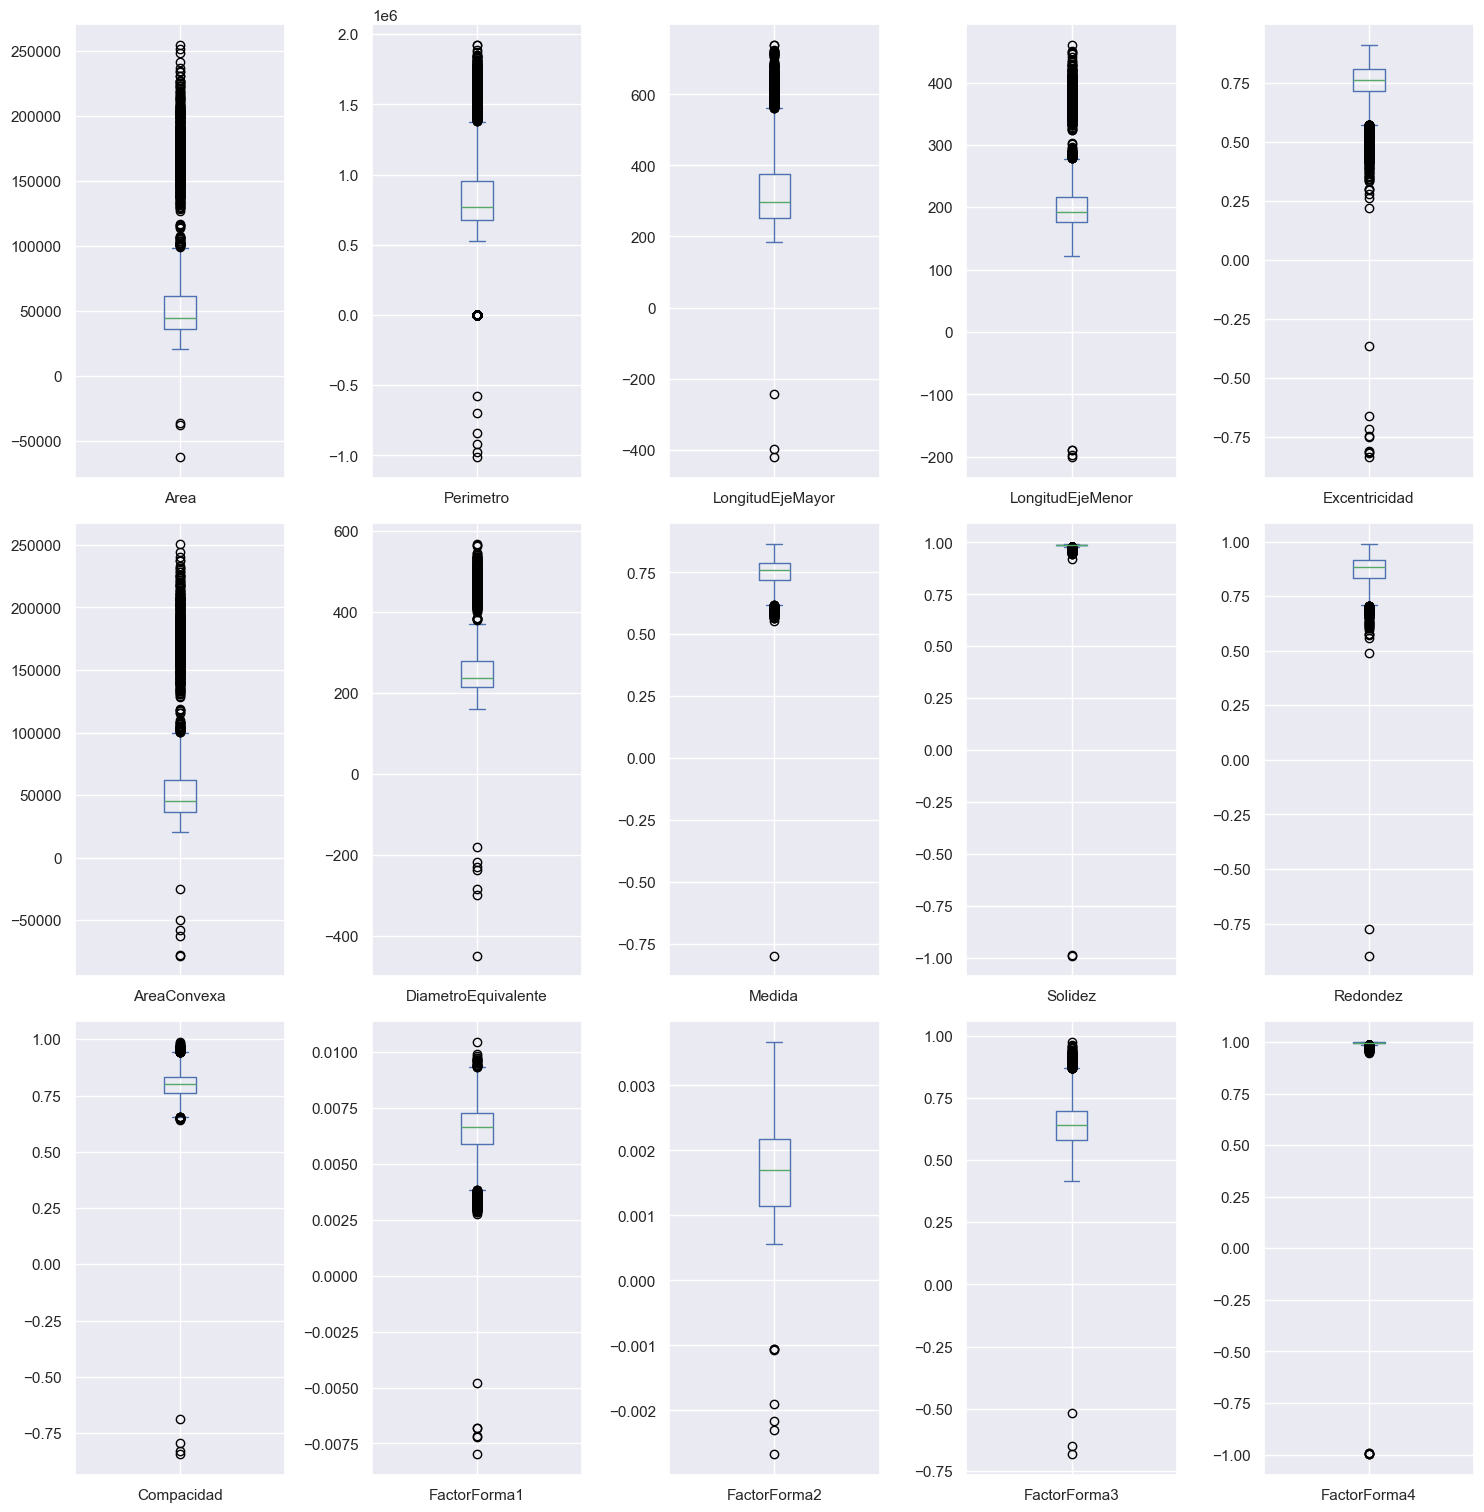

In [9]:
import matplotlib.pyplot as plt

df.plot(
    kind="box",
    subplots=True,
    layout=(int(len(df.columns) / 5) + 1, 5),  # filas, cols
    figsize=(15, 5 * (len(df.columns) // 5 + 1)),
    sharex=False,
    sharey=False,
)

plt.tight_layout()
plt.show()

In [10]:
# Revisar el contenido de las variables que no son numéricas, en este caso son categóricas
df[cat_cols].describe()

,ID,RelacionAspecto,DefectoVisible,MétodoSecado
count,14291,13825,11356,13704
unique,13611,4,2,6
top,G002981,Alargado,Normal,Lavado
freq,2,12047,9096,6260


In [11]:
# Revisar el contenido de las variables que son numéricas, en este caso son categóricas
df[num_cols].describe()

,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,Excentricidad,AreaConvexa,DiametroEquivalente,Medida,Solidez,Redondez,Compacidad,FactorForma1,FactorForma2,FactorForma3,FactorForma4
count,14291.000000,1.305400e+04,13890.000000,14291.000000,13687.000000,12868.000000,12368.000000,14291.000000,11985.000000,12228.000000,13641.000000,13172.000000,13185.000000,13813.000000,13132.000000
mean,53055.408999,7.729870e+05,319.985592,202.178613,0.749977,53575.397809,253.001741,0.749844,0.986774,0.873080,0.799242,0.006560,0.001712,0.643183,0.994292
std,29396.080372,3.266493e+05,86.378452,45.494541,0.099438,29566.387814,60.542330,0.050774,0.025947,0.063237,0.067643,0.001164,0.000601,0.100857,0.039081
min,-62716.000000,-1.012143e+06,-421.444657,-200.838672,-0.835004,-78423.000000,-448.402605,-0.798706,-0.989042,-0.896861,-0.843901,-0.007982,-0.002673,-0.683269,-0.998527
25%,36338.000000,6.768608e+05,253.319858,175.881052,0.715144,36720.000000,215.302463,0.718767,0.985597,0.832824,0.762127,0.005903,0.001151,0.581047,0.993663
50%,44660.000000,7.720345e+05,296.682345,192.437870,0.764392,45107.500000,238.579492,0.760232,0.988279,0.883353,0.800994,0.006645,0.001691,0.641648,0.996377
75%,61311.000000,9.554098e+05,376.548109,216.847844,0.810441,62109.250000,279.672481,0.786942,0.989991,0.916803,0.834405,0.007273,0.002169,0.696366,0.997889
max,254616.000000,1.921685e+06,738.860154,460.198497,0.911423,251082.000000,569.374358,0.866195,0.994378,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


<Figure size 3000x800 with 0 Axes>

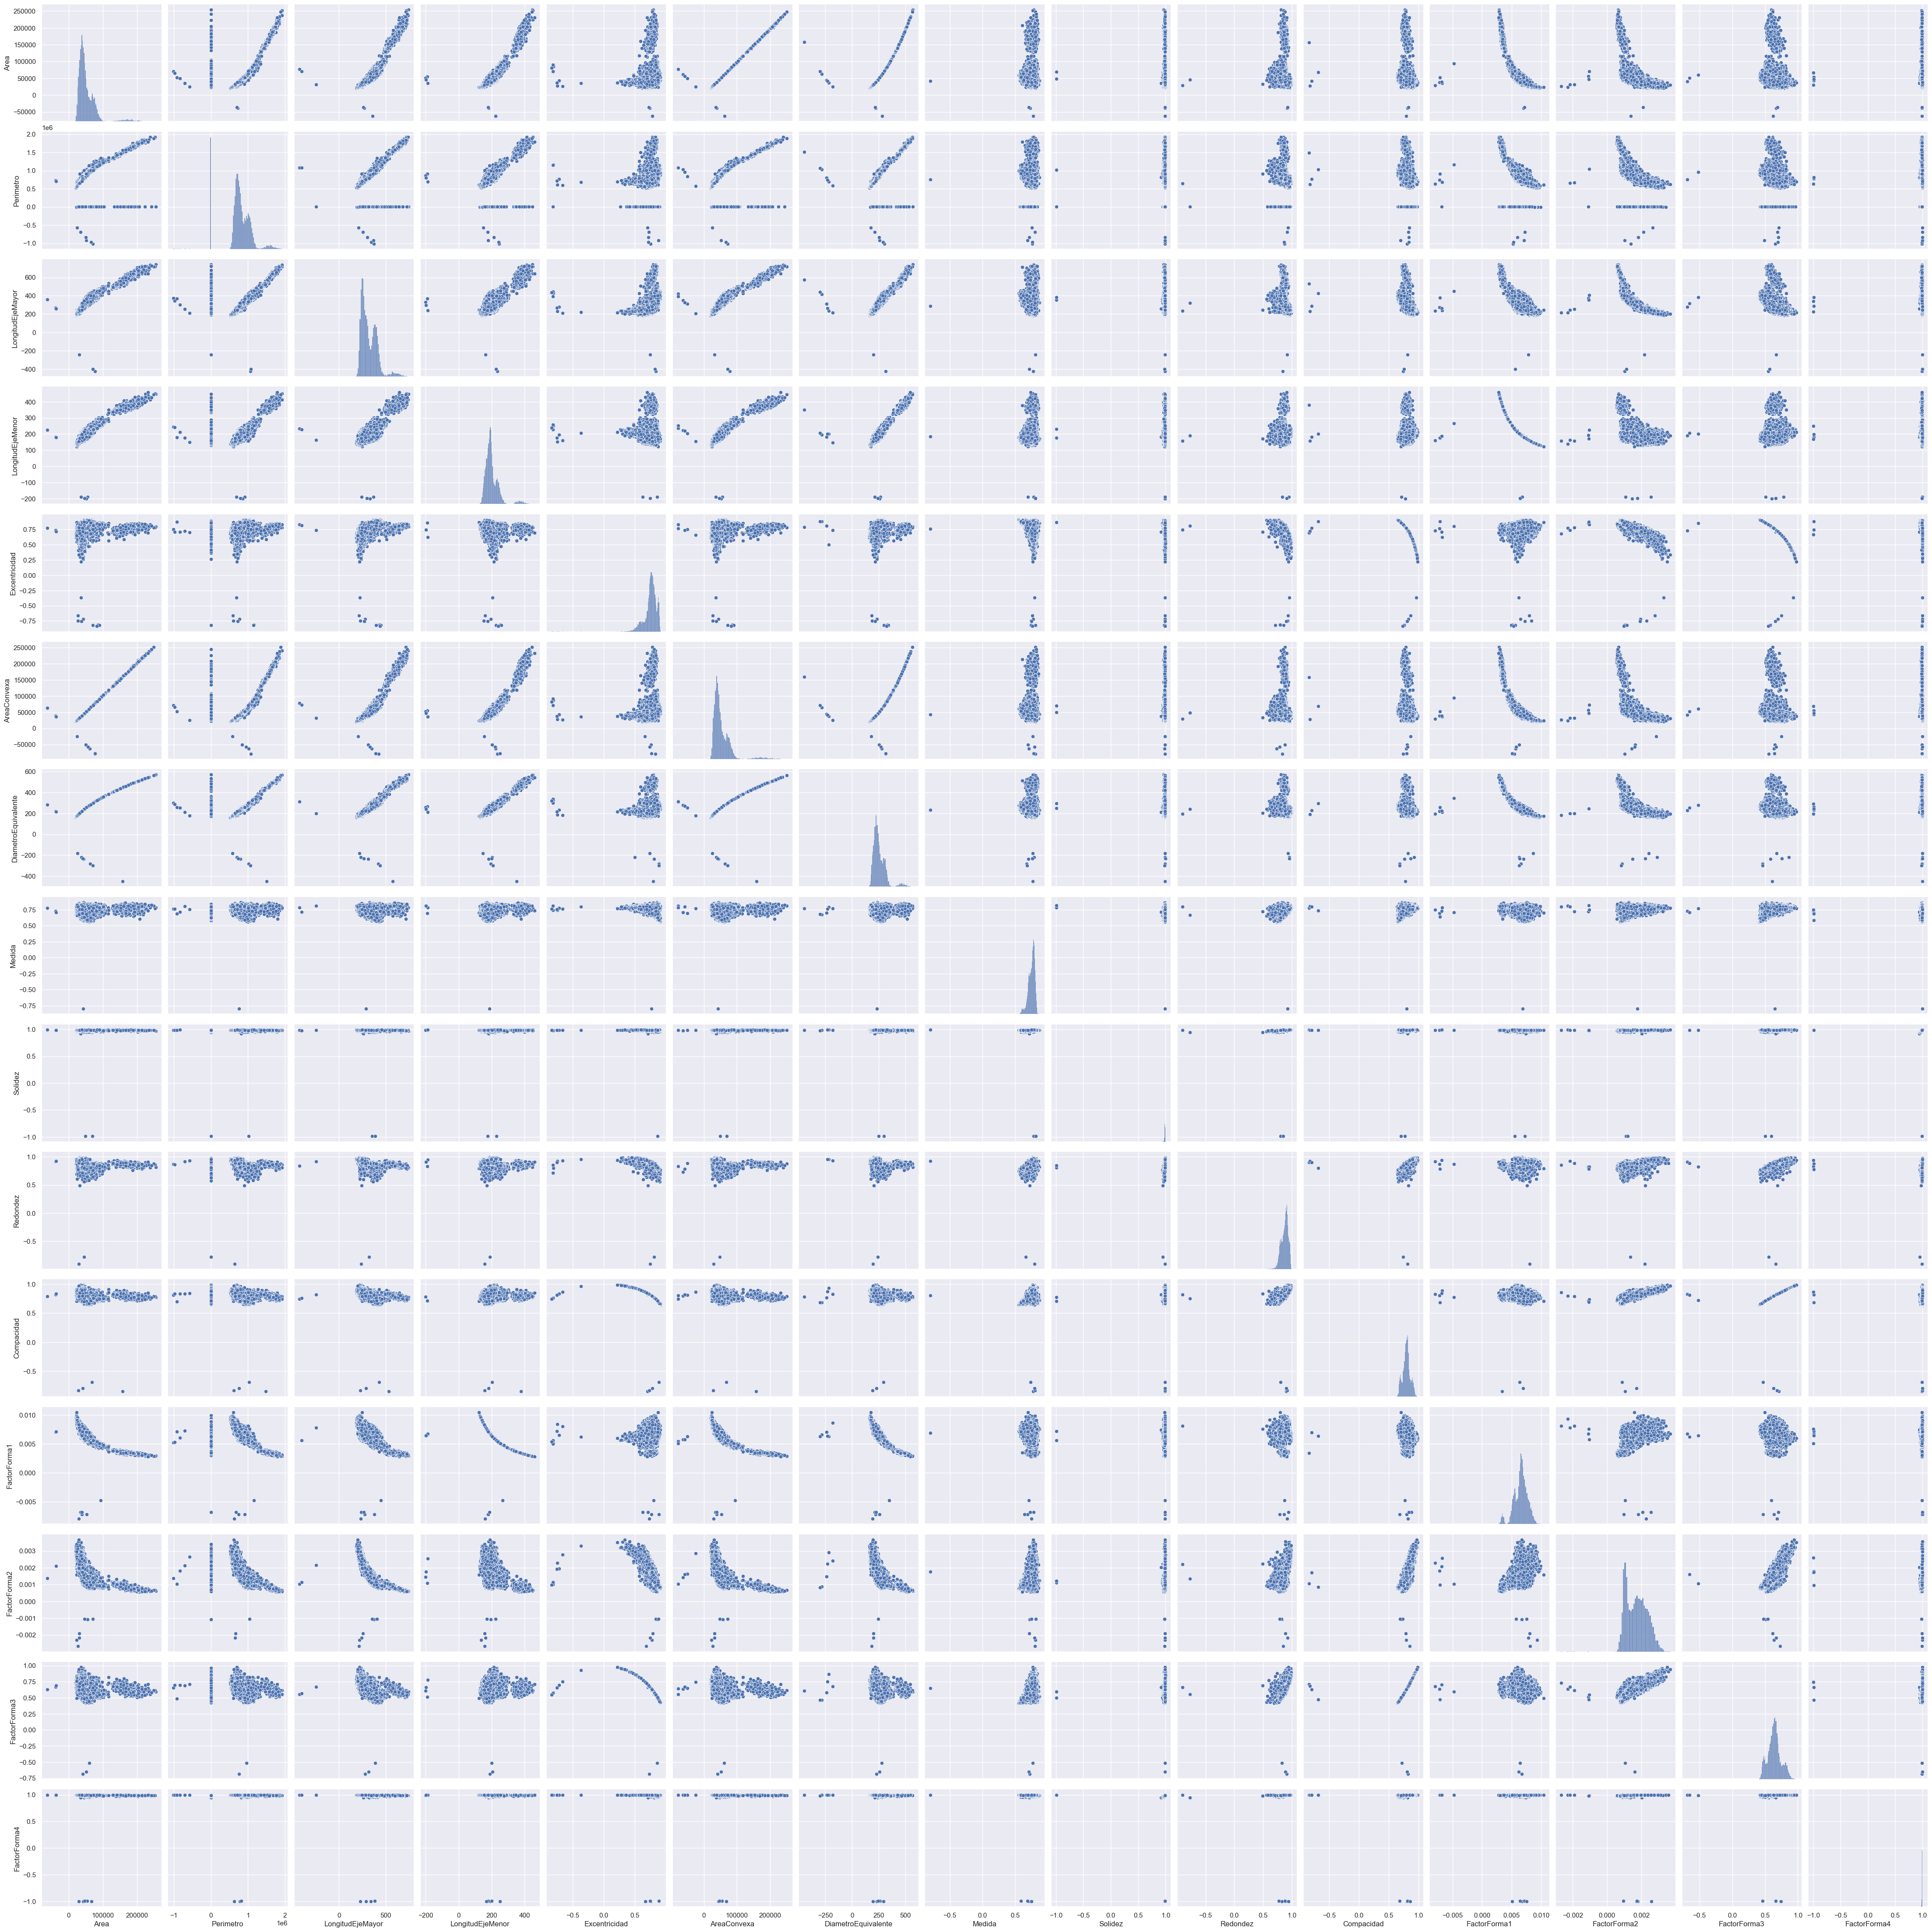

In [12]:
# Vámos las relaciones entre todas las variables numércias
plt.figure(figsize=(30, 8))
sns.pairplot(df[num_cols], height=3)

**Análisis** 
1. Observamos que se identifican varios grupos en gran parte de las variables, aproximadamente se observan entre 2 a 3 grupos entre las variables, con 1 o 2 grupos que tienen la mayos parte de los datos
  
2. Las variables categoricas tienes errores de consistencia, donde las caregorias de estas variables tienen el nombre mal escrito y lo toma como otra categoria diferente.

3.

In [13]:
# Consulto una muestra de datos para analizarlos mejor
df_cafe = df.copy()
df_cafe.sample(15)

,ID,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,RelacionAspecto,Excentricidad,AreaConvexa,DiametroEquivalente,Medida,Solidez,Redondez,Compacidad,FactorForma1,FactorForma2,FactorForma3,FactorForma4,DefectoVisible,MétodoSecado
6148,G011234,29702,631176.00,226.447220,167.565085,Alargado,0.672635,30053.0,194.467892,0.728562,0.988321,0.936903,0.858778,0.007624,0.002558,0.737500,0.996656,Normal,Natural
8623,G000663,37350,699848.00,238.172991,199.954331,Redondeado,0.543307,37637.0,218.072229,0.786283,0.992375,0.958281,0.915604,0.006377,0.002764,0.838331,0.998567,Normal,Lavado
6685,G008886,45172,818531.00,312.993885,184.212413,Alargado,0.808461,45867.0,239.822386,0.786845,0.984847,NaN,0.766221,0.006929,0.001473,0.587094,0.997527,NaN,Lavado
222,G010068,20548,524736.00,183.965251,142.672388,Redondeado,0.631299,20825.0,161.748342,0.759686,0.986699,NaN,0.879233,0.008953,0.003300,0.773051,0.996791,NaN,Lavado
11742,G006653,55325,930973.00,367.893315,193.452099,Alargado,0.850585,56255.0,NaN,0.721072,0.983468,0.802153,0.721429,0.006650,0.001111,0.520460,0.989774,Normal,Natural
265,G010935,28472,627578.00,219.748873,165.953667,Alargado,0.655498,28848.0,190.398730,0.694541,0.986966,NaN,0.866438,0.007718,0.002683,0.750714,0.994065,NaN,Natural
11672,G007124,60794,984123.00,396.834370,196.171213,Alargado,0.869268,NaN,278.218125,0.775681,0.989373,0.788809,0.701094,0.006528,0.000973,0.491533,0.994320,NaN,Lavado
4053,G009849,51150,841317.00,310.334134,210.613640,Alargado,0.734446,51593.0,255.198360,0.764231,0.991414,0.908105,0.822334,0.006067,0.001711,0.676233,0.996414,Normal,Lavado
4809,G008484,43398,782.63,294.264333,188.495993,NaN,0.767902,NaN,235.066054,0.827574,0.988745,0.890362,0.798826,0.006781,0.001703,0.638123,0.996185,Normal,Lavado
1326,G010408,26006,NaN,221.903769,149.426950,Alargado,0.739291,26248.0,181.966666,0.714117,0.990780,0.928014,0.820025,NaN,0.002380,0.672441,0.998597,normal,natural


### 3.2. Análisis de calidad de datos

Revisamos las dimensiones de calidad: unicidad, completitud, consistencia, validez.
En particular miramos si se presenta algún problema de calidad relacionado con la dimensión y pensamos en opciones para la corrección. 

### 3.2.1 Completitud - Análisis de valores nulos o vacíos

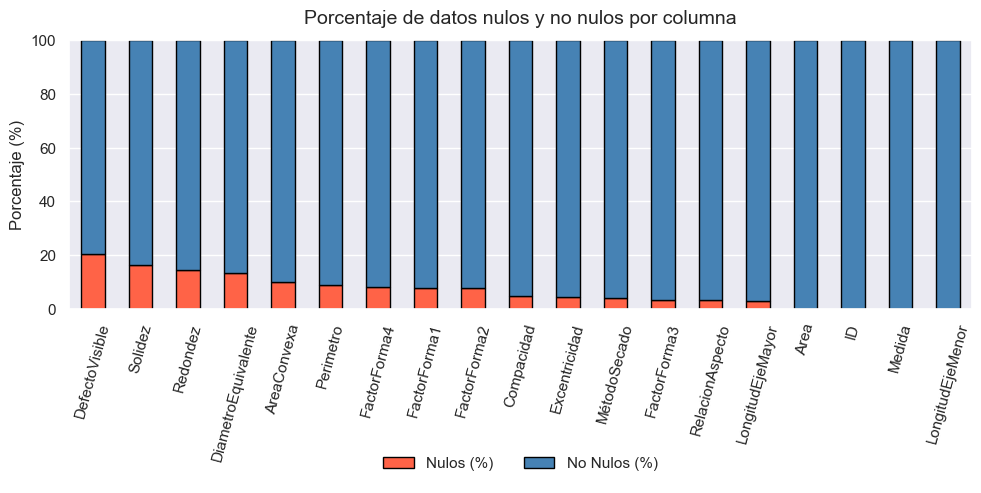

In [14]:
# Cálculo de porcentaje de valores nulos por columna
((df_cafe.isnull().sum() / df_cafe.shape[0])).sort_values(ascending=False)

# Calculamos % de nulos y no nulos
na_percent = df_cafe.isnull().sum() / df_cafe.shape[0] * 100
valid_percent = 100 - na_percent

df_na = pd.DataFrame(
    {"Nulos (%)": na_percent, "No Nulos (%)": valid_percent}
).sort_values("Nulos (%)", ascending=False)

# Gráfico apilado
df_na.plot(kind="bar",stacked=True,color=["tomato", "steelblue"],
           figsize=(10, 6),
            edgecolor="black")

plt.title("Porcentaje de datos nulos y no nulos por columna", fontsize=14, pad=12)
plt.ylabel("Porcentaje (%)", fontsize=12)
plt.xlabel(" ",)
plt.xticks(rotation=75)
plt.ylim(0, 100)  # Siempre hasta 100%
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.5), ncol=2, frameon=False)
plt.tight_layout()
plt.show()

In [15]:
df_cafe.isnull().sum()

ID                        0
Area                      0
Perimetro              1237
LongitudEjeMayor        401
LongitudEjeMenor          0
RelacionAspecto         466
Excentricidad           604
AreaConvexa            1423
DiametroEquivalente    1923
Medida                    0
Solidez                2306
Redondez               2063
Compacidad              650
FactorForma1           1119
FactorForma2           1106
FactorForma3            478
FactorForma4           1159
DefectoVisible         2935
MétodoSecado            587
dtype: int64

Ya que sabemos que hay varias columnas que son calculo de otras, entonces vamos a dejar solamente esas columnas a las cuales podriamos llamar como "obligatorias", es decir, que no pueden ser calculadas a partir de otra columna:

### Variables obligatorias
Estas siempre deben estar presentes y no deberían ser nulas:
- Área  
- Perímetro  
- LongitudEjeMayor  
- LongitudEjeMenor  
- ÁreaConvexa  

Tambien tendremos en cuenta variables como los factores avanzados, que sabemos que dependen de alguna otra caracteristica del grano pero no sabemos exactamente como se calculan y en cambio si pueden ser de utilidad
### Factores avanzados
Variables sintéticas que combinan métricas, útiles en contextos más complejos:
- Excentricidad
- FactorForma1  
- FactorForma2  
- FactorForma3  
- FactorForma4 

In [16]:
columnas_obligatorias = [
    'Area', 'Perimetro', 'LongitudEjeMayor', 'LongitudEjeMenor', 'AreaConvexa'
]
factores_avanzados = [
    'Excentricidad', 'FactorForma1', 'FactorForma2', 'FactorForma3', 'FactorForma4'
]
columnas_categoricas = ['DefectoVisible', 'MétodoSecado']
columnas_numericas = factores_avanzados + columnas_obligatorias
columnas_a_seleccionar = columnas_categoricas + columnas_obligatorias  + factores_avanzados 

df_cafe = df_cafe[columnas_a_seleccionar]

df_cafe.dropna(subset = columnas_obligatorias, inplace = True)



In [17]:
df_cafe.isnull().sum()

DefectoVisible      2348
MétodoSecado         464
Area                   0
Perimetro              0
LongitudEjeMayor       0
LongitudEjeMenor       0
AreaConvexa            0
Excentricidad        496
FactorForma1         892
FactorForma2         873
FactorForma3         390
FactorForma4         928
dtype: int64

In [18]:
df_cafe.head()

,DefectoVisible,MétodoSecado,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,AreaConvexa,Excentricidad,FactorForma1,FactorForma2,FactorForma3,FactorForma4
1,NaN,Natural,62764,1003767.0,409.207082,198.330199,64158.0,NaN,0.006520,0.000916,0.477237,0.984666
2,Normal,Natural,59965,994266.0,389.088529,197.967275,60910.0,0.860886,0.006489,0.001018,0.504326,0.991211
3,Normal,Lavado,55035,917.6,379.346822,185.390577,55591.0,0.872446,0.006893,0.001008,0.486941,0.996380
4,Normal,Lavado,39324,737773.0,262.520242,191.176858,39758.0,0.685326,0.006676,0.002174,0.726511,0.997630
5,NaN,Natural,50654,879938.0,357.233899,181.407743,51251.0,0.861468,0.007052,0.001111,NaN,0.995211


Aqui podemos ver que ya hemos tratado con los valores nulos de las variables numericas obligatorias,sin embargo, para las variables numericas "factores avanzados" lo haremos mas adelante, pues vamos a reemplazar los valores con la media de las respectivas columnas. Por ahora, vamos a trabajar con los valores de nulos de las variables categoricas

In [19]:
df_cafe[columnas_categoricas].isnull().sum()

DefectoVisible    2348
MétodoSecado       464
dtype: int64

In [20]:
df_cafe['DefectoVisible'].value_counts()

DefectoVisible
Normal    7268
normal    1814
Name: count, dtype: int64

- Entendemos que la para la variable DefectoVisible, basandonos en el diccionario de datos, que aquellos datos nulos se refieren a la otra categoria posible, es decir, Defectuoso
- Para la variable MetodoSecado crearemos la categoria "Desconocido"

In [21]:
df_cafe['DefectoVisible']=df_cafe['DefectoVisible'].fillna("Defectuoso")
df_cafe['MétodoSecado'] = df_cafe['MétodoSecado'].fillna("Desconocido")

In [22]:
df_cafe.head()

,DefectoVisible,MétodoSecado,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,AreaConvexa,Excentricidad,FactorForma1,FactorForma2,FactorForma3,FactorForma4
1,Defectuoso,Natural,62764,1003767.0,409.207082,198.330199,64158.0,NaN,0.006520,0.000916,0.477237,0.984666
2,Normal,Natural,59965,994266.0,389.088529,197.967275,60910.0,0.860886,0.006489,0.001018,0.504326,0.991211
3,Normal,Lavado,55035,917.6,379.346822,185.390577,55591.0,0.872446,0.006893,0.001008,0.486941,0.996380
4,Normal,Lavado,39324,737773.0,262.520242,191.176858,39758.0,0.685326,0.006676,0.002174,0.726511,0.997630
5,Defectuoso,Natural,50654,879938.0,357.233899,181.407743,51251.0,0.861468,0.007052,0.001111,NaN,0.995211





Antes de aplicar tecnicas de agrupacion, es importante manejar valores NA ya que los algoritmos propuestos no pueden manejar los datos incompletos drectamente. 

### 3.2.2 Unicidad

En este punto si se tienen las filas idénticas que representa duplicidad de los datos..

In [23]:
antes = df_cafe.shape[0]
df_cafe = df_cafe.drop_duplicates(keep="first")
despues = df_cafe.shape[0]
print("Filas eliminadas:", antes - despues)

Filas eliminadas: 386


In [24]:
# Verificamos que no hayan duplicados
df_cafe.duplicated().sum()

np.int64(0)

### 3.2.3 Consistencia

1. Observamos valores mal escritos en variables como `DefectoVisible`, `MétodoSecado`

In [25]:
# Revisamos los valores de la variable categórica 'DefectoVisible'
df_cafe.DefectoVisible.value_counts()

DefectoVisible
Normal        6980
Defectuoso    2259
normal        1805
Name: count, dtype: int64

In [26]:
df_cafe["DefectoVisible"] = df_cafe["DefectoVisible"].replace({"normal": "Normal"})
df_cafe.DefectoVisible.value_counts()

DefectoVisible
Normal        8785
Defectuoso    2259
Name: count, dtype: int64

In [27]:
# Revisamos los valores de la variable categórica 'MétodoSecado'
df_cafe.MétodoSecado.value_counts()

MétodoSecado
Lavado         4815
Natural        3543
lavado         1255
natural         930
Desconocido     443
Honey            46
honey            12
Name: count, dtype: int64

In [28]:
df_cafe["MétodoSecado"] = df_cafe["MétodoSecado"].replace(
    {"lavado": "Lavado", "natural": "Natural", "honey": "Honey"}
)
df_cafe.MétodoSecado.value_counts()

MétodoSecado
Lavado         6070
Natural        4473
Desconocido     443
Honey            58
Name: count, dtype: int64

In [29]:
df_cafe.describe()

,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,AreaConvexa,Excentricidad,FactorForma1,FactorForma2,FactorForma3,FactorForma4
count,11044.000000,1.104400e+04,11044.000000,11044.000000,11044.000000,10566.000000,10178.000000,10200.000000,10669.000000,10144.000000
mean,52859.038754,7.707116e+05,319.272438,201.922682,53538.684444,0.749328,0.006566,0.001720,0.644155,0.994888
std,29201.580643,3.241338e+05,86.137998,45.367719,29714.659307,0.100237,0.001171,0.000598,0.100116,0.020242
min,-38311.000000,-1.012143e+06,-421.444657,-200.838672,-78423.000000,-0.815195,-0.007982,-0.002157,-0.683269,-0.995589
25%,36295.250000,6.769668e+05,253.227334,175.840519,36676.000000,0.714850,0.005919,0.001159,0.583015,0.993763
50%,44523.000000,7.699280e+05,295.915641,192.397343,45026.500000,0.763892,0.006648,0.001704,0.642567,0.996400
75%,60969.250000,9.524692e+05,376.044012,216.205033,61842.000000,0.809610,0.007277,0.002174,0.696879,0.997893
max,248424.000000,1.921685e+06,738.144502,460.198497,251082.000000,0.908167,0.010451,0.003665,0.974767,0.999709


In [30]:
df_cafe.head()

,DefectoVisible,MétodoSecado,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,AreaConvexa,Excentricidad,FactorForma1,FactorForma2,FactorForma3,FactorForma4
1,Defectuoso,Natural,62764,1003767.0,409.207082,198.330199,64158.0,NaN,0.006520,0.000916,0.477237,0.984666
2,Normal,Natural,59965,994266.0,389.088529,197.967275,60910.0,0.860886,0.006489,0.001018,0.504326,0.991211
3,Normal,Lavado,55035,917.6,379.346822,185.390577,55591.0,0.872446,0.006893,0.001008,0.486941,0.996380
4,Normal,Lavado,39324,737773.0,262.520242,191.176858,39758.0,0.685326,0.006676,0.002174,0.726511,0.997630
5,Defectuoso,Natural,50654,879938.0,357.233899,181.407743,51251.0,0.861468,0.007052,0.001111,NaN,0.995211


En variables relacionadas con la medida del grano se tiene una escala mucho mayor a lo que deberia ser (`Área`, `Perimetro`, `LongitudEjeMayor`, `LongitudEjeMenor`, `)

### 3.2.4 Validez

Vamos a empezar revisando que los valores de las variables numericas tengan sentido (ej: valores de distancias no pueden ser menores a 0, o aquellos valores medidos en pixeles no puedes ser menores a 1 ni decimales.) A continuacion mostraremos la condicion para cada una de las variables.


### Condiciones de los atributos

- **ID** → Siempre presente, único por grano.  
- **Área** → Entero ≥ 1 (mínimo un píxel).  
- **Perímetro** → > 0.  
- **LongitudEjeMayor** → > 0.  
- **LongitudEjeMenor** → > 0.  
- **RelaciónAspecto** → > 0 (cociente de longitudes positivas).  
- **Excentricidad** → 0 ≤ valor ≤ 1.  
- **ÁreaConvexa** → ≥ Área y ≥ 1.  
- **FactorForma1, FactorForma2, FactorForma3, FactorForma4** → No tenemos informacion para concluir segun el diccionario de datos.  


Tambien eliminaremos aquellos valores anomalos usando el rango intercuartilico (IQR)

In [31]:
rangos = {
    "Area": (1, np.inf),                   # >= 1
    "Perimetro": (0, np.inf),              # > 0
    "LongitudEjeMayor": (0, np.inf),       # > 0
    "LongitudEjeMenor": (0, np.inf),       # > 0
    "AreaConvexa": (1, np.inf),            # >= 1
    "Excentricidad": (0, 1),               # [0, 1]
}

def eliminar_outliers_iqr(df, cols, k=1.5):
    df_filtrado = df.copy()
    for col in cols:
        if col in df.columns:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - k * IQR
            upper = Q3 + k * IQR
            df_filtrado = df_filtrado[(df_filtrado[col] >= lower) & (df_filtrado[col] <= upper)]
    return df_filtrado


df_cafe = eliminar_outliers_iqr(df_cafe, columnas_numericas)


# --- Aplicación de reglas ---
for col, (min_val, max_val) in rangos.items():
    if col in df_cafe.columns:
        df_cafe = df_cafe[(df_cafe[col] >= min_val) & (df_cafe[col] <= max_val)]



In [32]:
df_cafe.describe()

,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,AreaConvexa,Excentricidad,FactorForma1,FactorForma2,FactorForma3,FactorForma4
count,6113.000000,6.113000e+03,6113.000000,6113.000000,6113.000000,6113.000000,6113.000000,6113.000000,6113.000000,6113.000000
mean,47363.956813,8.189903e+05,307.503346,192.721845,47972.185997,0.760856,0.006773,0.001727,0.636629,0.995810
std,15869.782637,1.545464e+05,63.663993,28.527755,16135.641563,0.072284,0.000954,0.000520,0.085921,0.002631
min,20420.000000,5.247360e+05,183.601165,137.886809,20684.000000,0.573029,0.004629,0.000765,0.416499,0.987592
25%,35640.000000,6.986580e+05,254.316450,172.542499,36029.000000,0.723133,0.006196,0.001251,0.588118,0.994382
50%,43578.000000,7.825650e+05,292.380777,188.654698,44079.000000,0.763897,0.006777,0.001737,0.642849,0.996507
75%,56546.000000,9.428880e+05,365.469643,206.256507,57430.000000,0.806432,0.007410,0.002140,0.688892,0.997811
max,97743.000000,1.306551e+06,482.049644,276.231306,98773.000000,0.908167,0.009307,0.003304,0.818344,0.999709


Aqui tratamos ahora si con los nulos de las variables numericas "factores avanzados"

In [33]:
for col in factores_avanzados:
    if col in df_cafe.columns:
        df_cafe[col] = df_cafe[col].fillna(df_cafe[col].mean())

In [34]:
df_cafe.isnull().sum()

DefectoVisible      0
MétodoSecado        0
Area                0
Perimetro           0
LongitudEjeMayor    0
LongitudEjeMenor    0
AreaConvexa         0
Excentricidad       0
FactorForma1        0
FactorForma2        0
FactorForma3        0
FactorForma4        0
dtype: int64

## 3.3 Codificacion columnas categoricas y estandarizacion

A continuacion vamos a aplicar one hot encoder para la columna Metodo secado, y para la columna Defecto vsisible, aplicaremos label encoder al ser solo dos categorias (normal o defectuoso)

In [35]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler

def transformar_categoricas(df, columnas_categoricas):
    cat_cols_clave = columnas_categoricas
    for col in cat_cols_clave:
        if col in df.columns:
            if col in ['DefectoVisible']:
                le = LabelEncoder()
                df[col+'_ORD'] = le.fit_transform(df[col].astype(str))
            else:
                dummies = pd.get_dummies(df[col], prefix=col, dtype = 'int64',drop_first=True, )
                df = pd.concat([df, dummies], axis=1)
            
            if col!= "Content Type":
                df = df.drop(columns=[col])  # elimina la original
    return df

df_cafe = transformar_categoricas(df_cafe, columnas_categoricas)

df_cafe.head()


,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,AreaConvexa,Excentricidad,FactorForma1,FactorForma2,FactorForma3,FactorForma4,DefectoVisible_ORD,MétodoSecado_Honey,MétodoSecado_Lavado,MétodoSecado_Natural
2,59965,994266.0,389.088529,197.967275,60910.0,0.860886,0.006489,0.001018,0.504326,0.991211,1,0,0,1
4,39324,737773.0,262.520242,191.176858,39758.0,0.685326,0.006676,0.002174,0.726511,0.997630,1,0,1,0
6,42293,775769.0,290.699462,185.793277,42758.0,0.769103,0.006873,0.001722,0.637221,0.997021,1,0,0,1
13,38559,741248.0,249.168187,197.847533,39182.0,0.607876,0.006462,0.002493,0.790771,0.995893,1,0,1,0
14,30706,643256.0,236.017779,166.046313,31055.0,0.710663,0.007686,0.002336,0.701849,0.997607,1,0,1,0


Por ultimo, aplicamos la estandarizacion de los datos, para ahora si, poder entrenar nuestros modelos.

In [36]:

num_cols = df_cafe.select_dtypes(include=[np.number]).columns.tolist()

# separar continuas de binarias (para no escalar dummies)
def es_binaria(serie):
    vals = serie.dropna().unique()
    return len(vals) <= 2

cont_cols = [c for c in num_cols if not es_binaria(df_cafe[c])]
bin_cols  = [c for c in num_cols if es_binaria(df_cafe[c])]

scaler_minmax = MinMaxScaler()
scaler_std = StandardScaler()

df_final = df_cafe.copy()
if cont_cols:
    df_final[cont_cols] = scaler_minmax.fit_transform(df_final[cont_cols])
print("\nVariables numéricas normalizadas (MinMax):")
print(df_final[cont_cols].head())


Variables numéricas normalizadas (MinMax):
        Area  Perimetro  LongitudEjeMayor  LongitudEjeMenor  AreaConvexa  \
2   0.511426   0.600564          0.688519          0.434282     0.515130   
4   0.244481   0.272490          0.264431          0.385198     0.244260   
6   0.282878   0.321090          0.358850          0.346284     0.282677   
13  0.234587   0.276935          0.219693          0.433416     0.236884   
14  0.133026   0.151596          0.175630          0.203546     0.132810   

    Excentricidad  FactorForma1  FactorForma2  FactorForma3  FactorForma4  
2        0.858921      0.397604      0.099465      0.218558      0.298642  
4        0.335076      0.437630      0.554614      0.771472      0.828445  
6        0.585054      0.479879      0.376603      0.549272      0.778163  
13       0.103977      0.391919      0.680273      0.931385      0.685046  
14       0.410677      0.653655      0.618424      0.710101      0.826496  


## 4. Iteración 1. Primer modelo -- Fines pedagógicos
El objetivo de este primer modelo es comprender el funcionamiento general del algoritmo en términos de datos de entrada y resultado, con el fin de entender el aporte de esta tarea de agrupación al objetivo que se planteó el negocio. De la misma manera, se ilustra la forma como se evalúa el resultado obtenido, 

### 4.1 Preparar los datos
A nivel de preparación de datos debemos fijarnos en:
- A. Correcciones relacionadas con problemas de calidad de dato: nulos, duplicados, inconsistencia, diferencia de formatos, etc.
- B. Preparación relacionada con la tarea de aprendizaje
    - Selección de columnas a incluir de acuerdo con la tarea de aprendizaje a realizar y el conocimiento del contexto del negocio
    - ...
- C. Preparación de acuerdo con el algoritmo a utilizar, en este caso K-means
    Al revisar k-means vemos que el algoritmo trabaja únicamente con datos numéricos, y no nulos así que si vamos a incluir datos categóricos debemos transformarlos a numéricos y si tenemos datos nulos debemos transformalos y en el peor escenario retirarlos del modelo ya sea la fila que los incluye o toda la columna si el porcentaje de estos valores es alto.

<Span style="color:red">¿Será que el este algoritmo se ve afectado si las variables numéricas tienen magnitudes diferentes?</Span>

### 4.1.1 Identificar las variables a utilizar - les sugerimos dos de las numéricas 

In [37]:
#Preparación relacionada con el tipo B. Tipo de tarea de aprendizaje
#Vamos a seleccionar únicamente un subconjunto de variables numéricas para facilitar la creación del modelo
cols_select=["Number_of_Casualties","Speed_limit", "Number_of_Vehicles"]
df_bicis_model=df_bicis[cols_select].copy()


NameError: name 'df_bicis' is not defined

In [ ]:
#El número de duplicados con respecto al conjunto de datos es diferente, ya que se tiene un subconjunto de variables-
df_bicis_model.duplicated(keep = False).sum()

5333

In [ ]:
#Correcciones relacionadas con el tipo A. Calidad de datos
# Reemplazar los valores nulos por un valor diferente al contenido actual de las columnas
#En este punto hay que justificar la decisión. Por ejemplo, se trata de un 3% de filas y el experto estuvo de acuerdo con esta solución.
df_bicis_model=df_bicis[cols_select].copy()
#Eliminar duplicados
df_bicis_model.drop_duplicates(keep = 'first', inplace = True)
#Completar datos con valores nulos fillna(-99)

In [ ]:
df_bicis_model.duplicated(keep = False).sum()

0

In [ ]:
# Fijénse que el número de registros que nos queda es muy pequeño y podrá facilitar la interpretación
# continuaremos solo para explicar el funcionamiento del algoritmo y la forma de analizar el resultado.
df_bicis_model.shape

(19, 3)

In [ ]:
#Si es crírito el caso
#sns.pairplot(df_bicis_model.dropna(), height=3,vars=['Light_Conditions','Number_of_Casualties'],kind='scatter')

In [ ]:
df_bicis_model

,Number_of_Casualties,Speed_limit,Number_of_Vehicles
0,1,30.0,1
3,2,30.0,1
45,1,50.0,1
49,2,30.0,2
56,1,60.0,1
62,1,40.0,1
88,1,70.0,1
101,1,20.0,1
156,2,40.0,1
175,2,20.0,1


### 4.3 Construir el modelo
¿Qué función de scikilearn utilizar para realizar k-means y qué parámetros requiere?

In [ ]:
# El negocio quiere que empecemos con calma, así que nos sugiere crear dos agrupaciones - k=2
model_kmeans = KMeans(n_clusters=2, random_state=0) 


In [ ]:
#Si te sale el error: AttributeError: 'NoneType' object has no attribute 'split'
# al ejecutar este comando, puedes actualizr el  "threadpoolctl" a  3.1.0 con el comando pip install threadpoolctl==3.1.0
# más información: https://github.com/scikit-learn/scikit-learn/issues/24238
#Para ver la versión actual utiliza: print(sklearn.show_versions())
res_kmeans = model_kmeans.fit(df_bicis_model)

C:\Users\Maria Del Pilar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [ ]:
#Consultar la etiqueta de la agrupación asignado a cada fila 
res_kmeans.labels_

array([1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0])

Es dificil de entender el resultado general viendo solo la etiqueta generada por el algoritmo, que corresponde al número de grupo al que pertenece una fila, por lo que acudimos a la visualización en gráficas.

### 4.4. Visualizar el resultado

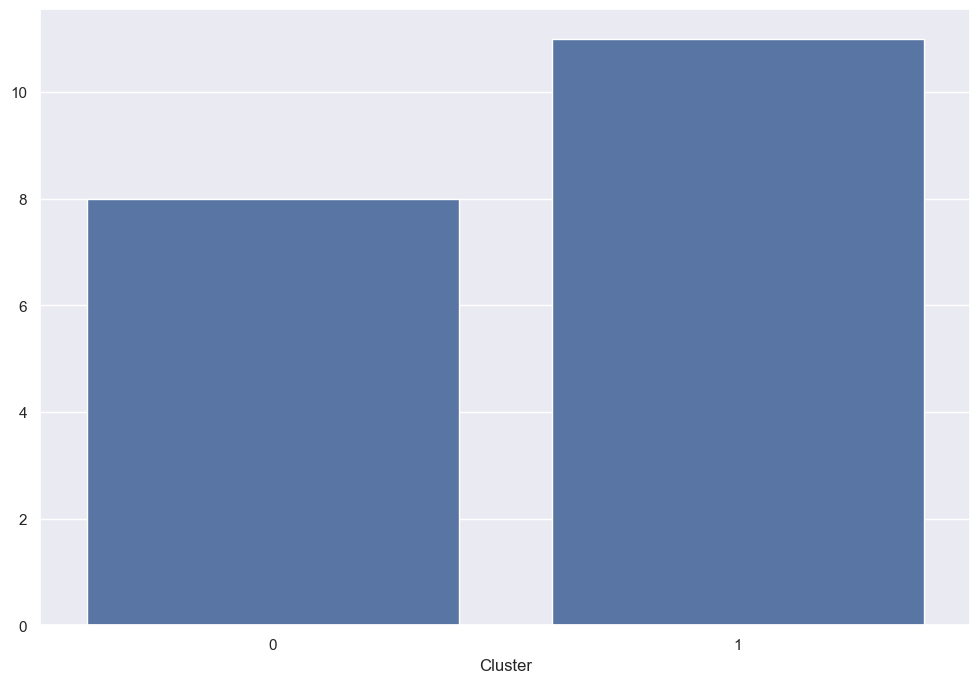

In [ ]:
# Revisar la cantidad de registros en los grupos resultado
labels = res_kmeans.labels_
df_bicis_model['Cluster'] = labels

cluster_distrib = df_bicis_model['Cluster'].value_counts()

fig=plt.figure(figsize=(12,8))
sns.barplot(x=cluster_distrib.index, y=cluster_distrib.values, color='b');


In [ ]:
# Revisar el número exacto de elementos por clúster y las variables utilizadas.
df_bicis_model.groupby('Cluster').count()

,Number_of_Casualties,Speed_limit,Number_of_Vehicles
Cluster,,,
0,8,8,8
1,11,11,11


In [ ]:
#Transformar el contenido de las columnas a arreglo para facilitar aplicar funciones como las de visualización
cols_number = df_bicis_model.to_numpy()
cols_number

array([[ 1., 30.,  1.,  1.],
       [ 2., 30.,  1.,  1.],
       [ 1., 50.,  1.,  0.],
       [ 2., 30.,  2.,  1.],
       [ 1., 60.,  1.,  0.],
       [ 1., 40.,  1.,  1.],
       [ 1., 70.,  1.,  0.],
       [ 1., 20.,  1.,  1.],
       [ 2., 40.,  1.,  1.],
       [ 2., 20.,  1.,  1.],
       [ 2., 60.,  1.,  0.],
       [ 4., 30.,  1.,  1.],
       [ 2., 15.,  1.,  1.],
       [ 3., 30.,  1.,  1.],
       [ 2., 50.,  1.,  0.],
       [ 3., 50.,  1.,  0.],
       [ 3., 20.,  1.,  1.],
       [ 2., 60.,  2.,  0.],
       [ 2., 70.,  1.,  0.]])

In [ ]:
df_bicis_model

,Number_of_Casualties,Speed_limit,Number_of_Vehicles,Cluster
0,1,30.0,1,1
3,2,30.0,1,1
45,1,50.0,1,0
49,2,30.0,2,1
56,1,60.0,1,0
62,1,40.0,1,1
88,1,70.0,1,0
101,1,20.0,1,1
156,2,40.0,1,1
175,2,20.0,1,1


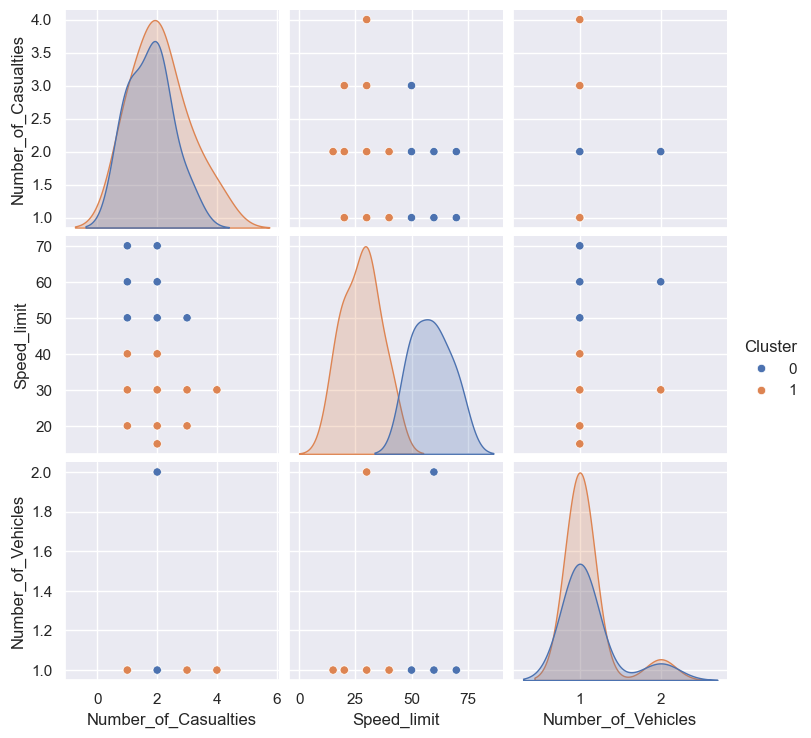

In [ ]:
sns.pairplot(data=df_bicis_model, hue="Cluster")

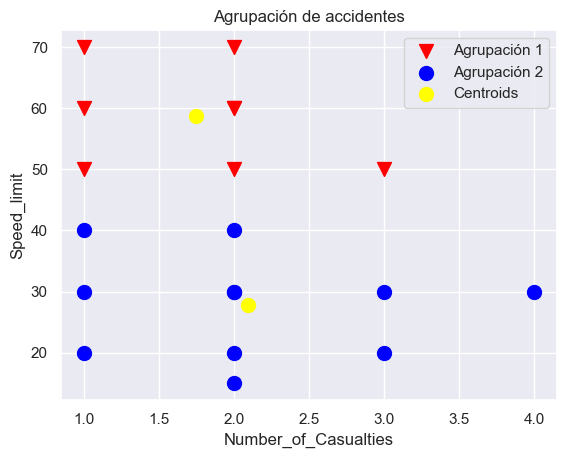

In [ ]:
# Ver gráficamente en dos dimensiones -de acuerdo con el análisis de la gráfica anterior- las diferentes agrupaciones para poderlas describir mejor
# Recuerden que el describir los grupos es quizás una de las actividades más difíciles a nivel de la tarea de agrupación.
plt.scatter(cols_number[labels == 0, 0], cols_number[labels == 0, 1], s = 100, marker='v', c = 'red', label = 'Agrupación 1')
plt.scatter(cols_number[labels == 1, 0], cols_number[labels == 1, 1], s = 100, marker='o', c = 'blue', label = 'Agrupación 2')

plt.scatter(res_kmeans.cluster_centers_[:, 0], res_kmeans.cluster_centers_[:, 1], s = 100, c = 'yellow', label = 'Centroids')
plt.title('Agrupación de accidentes')
plt.xlabel(cols_select[0])
plt.ylabel(cols_select[1])
plt.legend()
plt.show()


In [ ]:
# Revisemos los valores de los centroides de los clústeres generados. Esta información puede ser útil durante la evaluación cualitativa del modelo
print('Centroides: [[',cols_select[0], ' ' , cols_select[1], ']]', res_kmeans.cluster_centers_)

Centroides: [[ Number_of_Casualties   Speed_limit ]] [[ 1.75       58.75        1.125     ]
 [ 2.09090909 27.72727273  1.09090909]]


### 4.5 Evaluar la calidad del modelo construido

Se identifican dos tipos de evaluación: cuantitativa y cualitativa.
Desde el punto de vista cuantitativo vamos a utilizar la "silueta" que es lo que observamos en la celda siguiente.

In [ ]:
#Creamos una función basada en el concepto de silueta
def plot_silhouette(data, 
                    labels,
                   ylabel = 'Grupos',
                   xlabel = "Coeficiente de silueta",
                   title = 'Gráfica de silueta'):
    '''
    Graficar la silueta de los clusters
    
    Parametros
    ----------
    data : np.array
        El arreglo con los datos
    labels : np.array
        El arreglo con las etiquetas correspondientes
    ylabel  string
        La etiqueta del eje y
    xlabel : string
        La etiqueta del eje x
    title : string
        El titulo de la gráfica        
    '''
    cluster_labels = np.unique(labels)
    print(cluster_labels)
    n_clusters = cluster_labels.shape[0]
    silhouette_vals = silhouette_samples(data,
                                        labels,
                                        metric='euclidean')
    y_ax_lower, y_ax_upper = 0, 0
    yticks = []
    for i, c in enumerate(cluster_labels):
        c_silhouette_vals = silhouette_vals[labels == c]
        c_silhouette_vals.sort()
        y_ax_upper += len(c_silhouette_vals)
        color = cm.jet(float(i) / n_clusters)
        plt.barh(range(y_ax_lower, y_ax_upper),
                        c_silhouette_vals,
                        height=1.0,
                        edgecolor='none',
                        color=color)
        yticks.append((y_ax_lower + y_ax_upper) / 2.)
        y_ax_lower += len(c_silhouette_vals)
    silhouette_avg = np.mean(silhouette_vals)
    plt.axvline(silhouette_avg,
                color="red",
                linestyle="--")
    plt.yticks(yticks, cluster_labels+1)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    plt.title(title)
    plt.show()

[0 1]


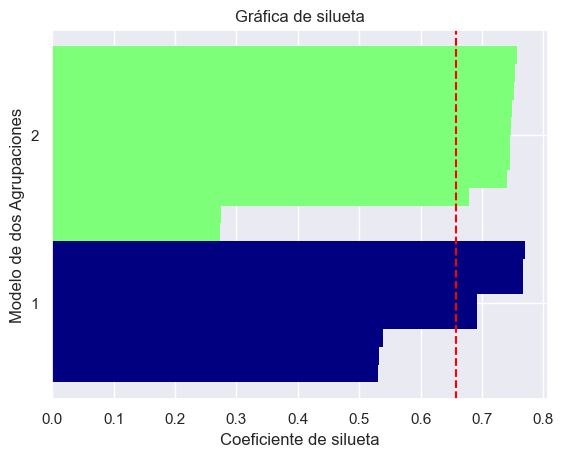

In [ ]:
# Esta función puede tardar varios minutos
# Un valor cercano a 1 es un indicador de un bueno modelo. Revisa la teoría para comprender mejor el concepto
plot_silhouette(data = df_bicis_model, 
                labels = res_kmeans.labels_, 
                ylabel = 'Modelo de dos Agrupaciones')

La silueta es una medida intrínseca ya que no se conoce el resultado de esta tarea).  Se define en términos de qué tan compactos y separados están los clúster o grupos identificados.

**Compactos:** Distancia promedio al interior de un clúster
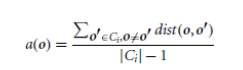

**Separados:** Mínima distancia promedio a otro clúster
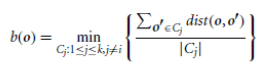

**Silueta:** Los valores cercanos a "1" son los mejores.
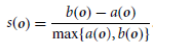

### 4.5 Analizar y concluir
Desde el punto de vista cuantitativo se identifica un buen valor de la silueta, cercano a 0.7, aunque hay que revisar los regisstros más lejanos a 1, para identificar lo que puede estar sucediendo y si es necesario regresar a la fase de preparación de los datos para ajustarlos y volver a construir el modelo. En este caso se observa que en el grupo 1(el morado en la gráfica) ha registros con una silueta por debajo de 0.3 y en el grupo 2 (verde en la gráfica), hay registros con siluetas por debajo a 0.6. Es posible que esos valores sean atípicos. 

A nivel cualitativo, se observa que la variable speed_limit es la varible que aporta más en las agrupaciones generadas, (ver el resultado de la celda con la instrucción -sns.pairplot(data=df_bicis_model, hue="Cluster")-. 
Esto puede llevar a que un funcionario, en este caso de secretaría de movilidad, proponga disminuir velocidades en ciertos tramos o fortalecer el cumplimiento del límite de  velocidad si ya se estableció y es apropiado.
Sin embargo, recordemos que no se ha hecho un tratamiento adecuado de variables ni de ajuste de hiperparámetros, por lo cual este modelo no es adecuado utilizarlo en el ambiente de BiciAlpes.

## 5. Segundo modelo: K-means (Juan Esteban Quiroga)
Para este modelo utilizaremos el algoritmo K-means o tambien llamado Lloyd–Forgy para la tarea de agrupacion, a continuacion vamos a ver los criterios para la seleccion del modelo.

- El algoritmo k-means es un algoritmo eficiente y muy rapido, lo que nos permitira encontrar rapidamente el numero k mas optimo.
- No es necesario hacer mas adecuaciones a los datos de los que ya hicimos en la seccion de preparacion y entendimiento de los datos.
- El algoritmo responde al objetivo de la tarea (clustering).
- Se esperan datos de tamaño esferico o similares, lo que funciona bien con el algoritmo de k-means 

### 5.1 Encontrar el k optimo

In [ ]:
df_processed = df_cafe.copy()

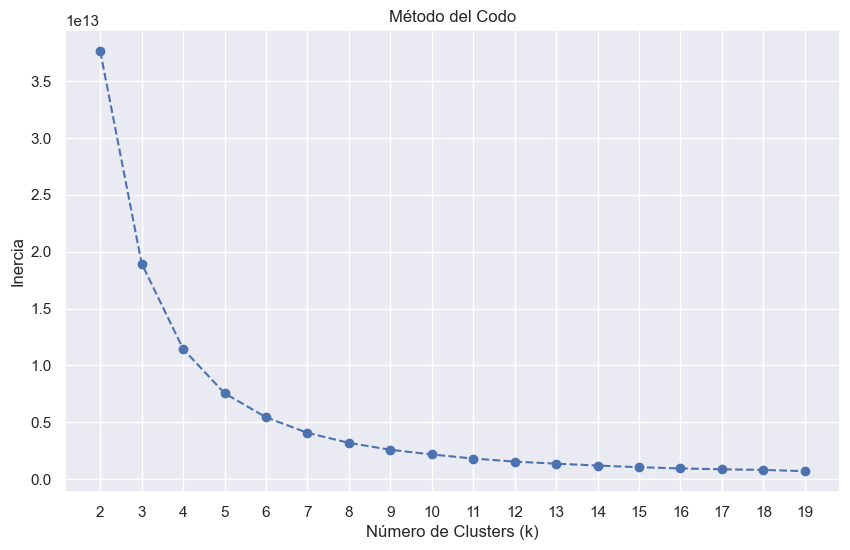

In [48]:
inertia = []
k_range = range(2, 20) 

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(df_processed)
    inertia.append(kmeans.inertia_)

# Graficar los resultados
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.xticks(k_range)
plt.grid(True)
plt.show()

Para este caso tomaremos el k=5 como el 'Codo' o el k optimo. Pues se genera el cambio de direccion mas evidente.

### 5.2 Entrenamiento del modelo

In [ ]:
k_optimo = 5

kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init='auto')
clusters = kmeans_final.fit_predict(df_processed)


df_processed['cluster'] = clusters

print(f"\n--- Se encontraron {k_optimo} clusters. Primeras 5 filas con su cluster asignado: ---")
print(df_processed.head())

# --- C) Analizar las características de cada cluster ---
# Agrupa por cluster y calcula la media de las características importantes
# ¡Esto te dirá QUÉ SIGNIFICA cada cluster!
cluster_analysis = df_processed.groupby('cluster').mean()




--- Se encontraron 5 clusters. Primeras 5 filas con su cluster asignado: ---
     Area  Perimetro  LongitudEjeMayor  LongitudEjeMenor  AreaConvexa  \
2   59965   994266.0        389.088529        197.967275      60910.0   
4   39324   737773.0        262.520242        191.176858      39758.0   
6   42293   775769.0        290.699462        185.793277      42758.0   
13  38559   741248.0        249.168187        197.847533      39182.0   
14  30706   643256.0        236.017779        166.046313      31055.0   

    Excentricidad  FactorForma1  FactorForma2  FactorForma3  FactorForma4  \
2        0.860886      0.006489      0.001018      0.504326      0.991211   
4        0.685326      0.006676      0.002174      0.726511      0.997630   
6        0.769103      0.006873      0.001722      0.637221      0.997021   
13       0.607876      0.006462      0.002493      0.790771      0.995893   
14       0.710663      0.007686      0.002336      0.701849      0.997607   

    DefectoVisible_O


--- DataFrame reducido a 2D con PCA (primeras 5 filas): ---
   Componente Principal 1  Componente Principal 2  cluster
0           176058.539837            -7150.352635        2
1           -82026.354208              219.854123        1
2           -43816.992193            -1027.191132        1
3           -78722.170872            -1215.520018        1
4          -177323.736919             1591.253271        4


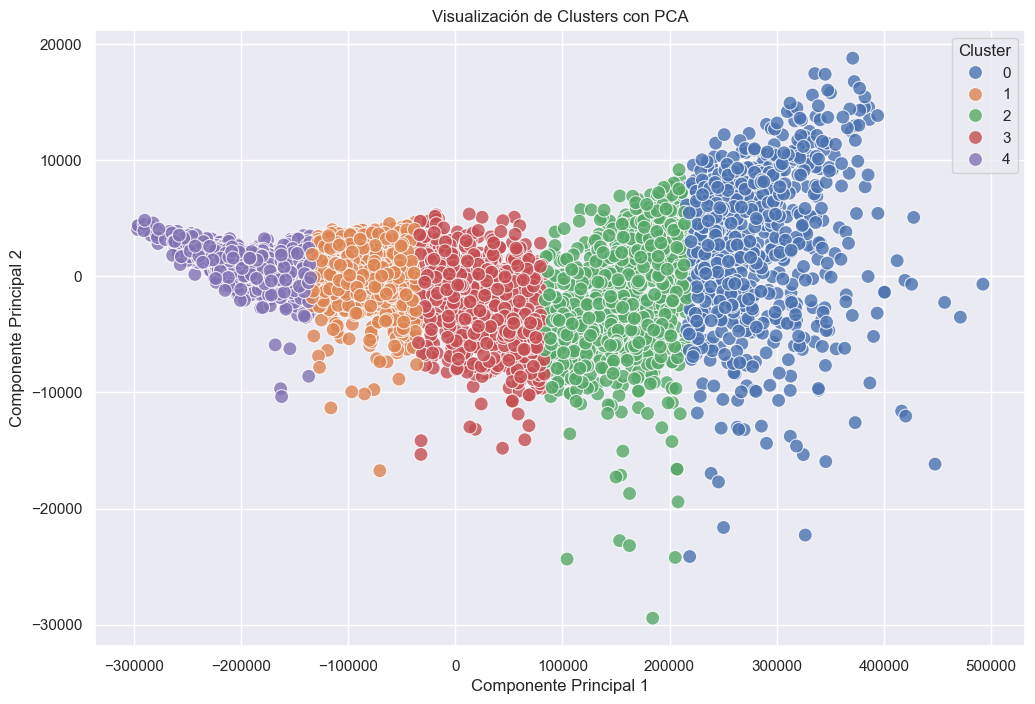

In [46]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Reducir la dimensionalidad con PCA ---
# Tomamos los datos con los que se entrenó el modelo (sin la columna 'cluster')
features_para_pca = df_processed.drop('cluster', axis=1)

# Configuramos PCA para reducir los datos a 2 componentes
pca = PCA(n_components=2)
componentes_principales = pca.fit_transform(features_para_pca)

# Creamos un nuevo DataFrame con los dos componentes principales
df_pca = pd.DataFrame(data=componentes_principales, columns=['Componente Principal 1', 'Componente Principal 2'])

# Añadimos la columna de clusters que ya habíamos calculado
df_pca['cluster'] = clusters

print("\n--- DataFrame reducido a 2D con PCA (primeras 5 filas): ---")
print(df_pca.head())


# --- 2. Graficar los resultados ---
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x="Componente Principal 1", 
    y="Componente Principal 2",
    hue="cluster",
    data=df_pca,
    palette="deep", # Puedes usar otras paletas como 'viridis', 'plasma', etc.
    s=100, # Tamaño de los puntos
    alpha=0.8 # Transparencia de los puntos
)

plt.title('Visualización de Clusters con PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

<Span style="color:red"> ¿Cómo me devuelvo y obtengo los valores originales para los análisis?</Span>

In [ ]:
df_bicis_model2.describe()

,Number_of_Casualties,Speed_limit,Number_of_Vehicles,Madrugada,Mañana,Noche,Tarde
count,5338.000000,5338.000000,5338.000000,5338.000000,5338.000000,5338.000000,5338.000000
mean,1.118022,33.522855,1.001124,0.001124,0.315474,0.276695,0.406707
std,0.330694,10.206576,0.033511,0.033511,0.464748,0.447406,0.491265
min,1.000000,15.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,30.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,30.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,30.000000,1.000000,0.000000,1.000000,1.000000,1.000000
max,4.000000,70.000000,2.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
#Guardar el nombre de las variables a utilizar en el modelo, incluyendo las nuevas columnas creadas relacionadas conla variable Time (Mañana, noche, tarde)
list_cols_transformed =np.array(enc.categories_[0]).tolist()
cols_transformed = cols_number+list_cols_transformed
cols_transformed

['Number_of_Casualties',
 'Speed_limit',
 'Number_of_Vehicles',
 'Madrugada',
 'Mañana',
 'Noche',
 'Tarde']

In [ ]:
# Vamos a llevar al mismo dominio las diferentes variables
# ¿Entiendes por qué? En este punto puedes revisar otras opciones como la de estandarización o RobustScaler.
mms= MinMaxScaler()
# transform data
df_bicis_prep_norm = mms.fit_transform(df_bicis_model2[cols_transformed])
df_bicis_model2_norm = pd.DataFrame(df_bicis_prep_norm, columns =cols_transformed)
df_bicis_model2_norm['Time'] = df_bicis_model2['Time']

In [ ]:
df_bicis_model2_norm

,Number_of_Casualties,Speed_limit,Number_of_Vehicles,Madrugada,Mañana,Noche,Tarde,Time
0,0.000000,0.272727,0.0,0.0,1.0,0.0,0.0,Mañana
1,0.000000,0.272727,0.0,0.0,1.0,0.0,0.0,Mañana
2,0.000000,0.272727,0.0,0.0,0.0,0.0,1.0,Tarde
3,0.333333,0.272727,0.0,0.0,0.0,0.0,1.0,Tarde
4,0.333333,0.272727,0.0,0.0,1.0,0.0,0.0,Mañana
...,...,...,...,...,...,...,...,...
5333,0.000000,0.090909,0.0,0.0,0.0,0.0,1.0,Tarde
5334,0.333333,0.272727,0.0,0.0,0.0,1.0,0.0,Noche
5335,0.000000,0.272727,0.0,0.0,0.0,0.0,1.0,Tarde
5336,0.000000,0.272727,0.0,0.0,0.0,1.0,0.0,Noche


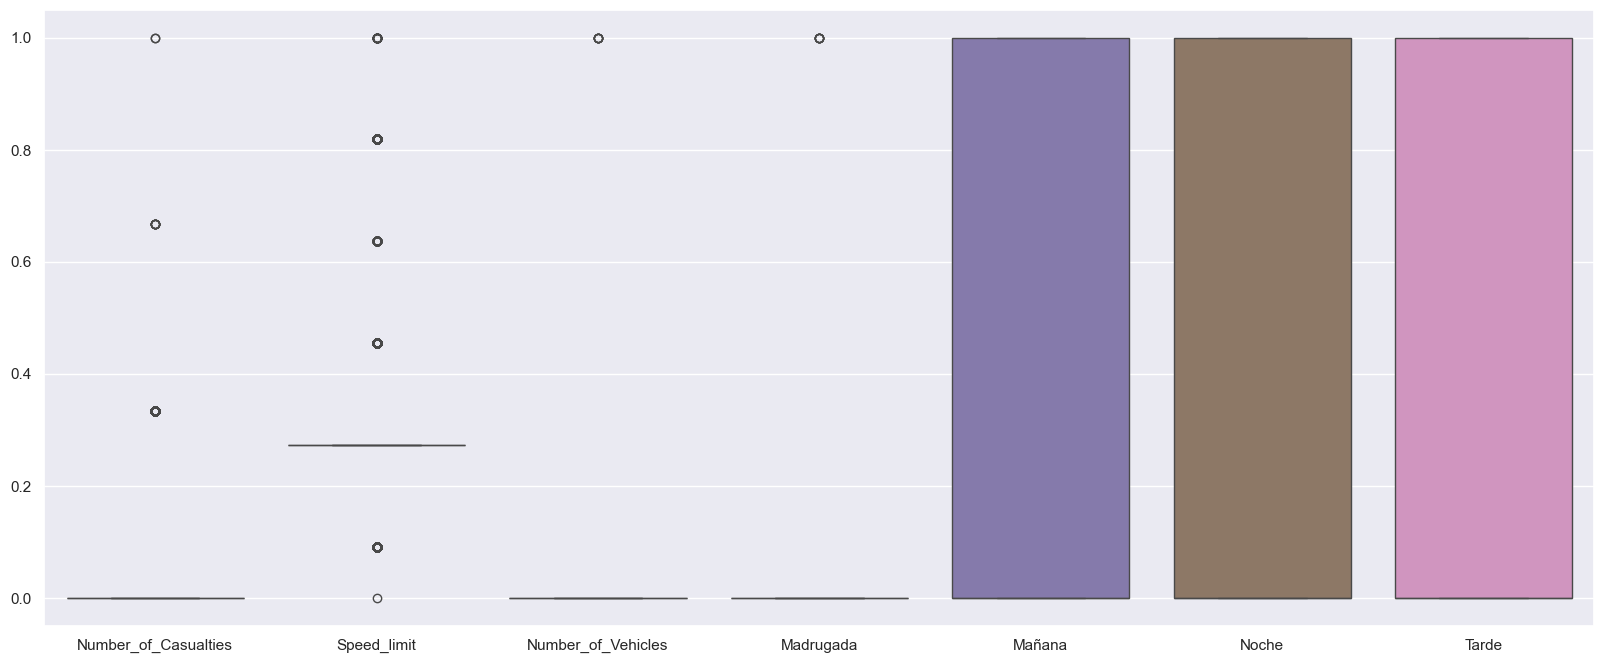

In [ ]:
#Visualización de todas las variables numéricas de iipo int luego de la transformación
#¿Qué pasó con los valores atípicos?
fig=plt.figure(figsize=(20,8))
ax = sns.boxplot(data=df_bicis_model2_norm, orient="v")

### 5.2. Encontrar el número óptimo de clústeres utilizando el método del codo

El método del codo consiste en ejecutar con diferentes k el algoritmo y medir la métrica de dispersión. Esta métrica para el caso de la implementación de KMeans en scikitlearn, corresponde a la sumna de distanciass al cuadrado entre los puntos de un cluster y su centroide.

In [ ]:
def plot_distortion(data,
                    k_min=1, 
                    k_max=11,
                    ylabel = 'Distortion',
                    xlabel = 'Number of clusters',
                    title = 'Distortion Plot'):
    '''
    Graficar el codo de los clusters
    
    Parametros
    ----------
    data : np.array
        El arreglo con los datos
    k_min : int
        Valor mínimo para k
    k_max : int
        Valor máximo para k
    xlabel : string
        La etiqueta del eje x
    ylabel  string
        La etiqueta del eje y    
    title : string
        El titulo de la gráfica  
    '''
    distortions = []
    for i in range(k_min, k_max):
        km = KMeans(n_clusters=i,
                 init='k-means++',
                 n_init=10,
                 max_iter=300,
                 random_state=0)
        km.fit(data)
        distortions.append(km.inertia_)
    plt.plot(range(k_min,k_max), distortions, marker='o')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

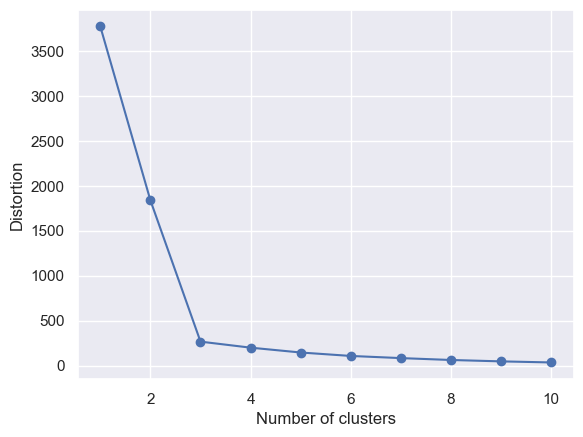

In [ ]:
# En este gráfico vemos el punto en que cambia la pendiente y ese es el número sugerido para el valor de k o número de grupos.
# En este caso un valor de 3
plot_distortion(df_bicis_model2_norm[cols_transformed],1,11)

### 5.3. Construir el nuevo modelo con el número de clústeres obtenido

In [ ]:
#En este punto generamos el modelo, con los datos preparados y la selección del número de grupos apoyada con el gráfico de silueta.
kmeans2 = KMeans(n_clusters=3, random_state=0) 
res_kmeans2 = kmeans2.fit(df_bicis_model2_norm[cols_transformed])


In [ ]:
df_bicis_model2_norm

,Number_of_Casualties,Speed_limit,Number_of_Vehicles,Madrugada,Mañana,Noche,Tarde,Time
0,0.000000,0.272727,0.0,0.0,1.0,0.0,0.0,Mañana
1,0.000000,0.272727,0.0,0.0,1.0,0.0,0.0,Mañana
2,0.000000,0.272727,0.0,0.0,0.0,0.0,1.0,Tarde
3,0.333333,0.272727,0.0,0.0,0.0,0.0,1.0,Tarde
4,0.333333,0.272727,0.0,0.0,1.0,0.0,0.0,Mañana
...,...,...,...,...,...,...,...,...
5333,0.000000,0.090909,0.0,0.0,0.0,0.0,1.0,Tarde
5334,0.333333,0.272727,0.0,0.0,0.0,1.0,0.0,Noche
5335,0.000000,0.272727,0.0,0.0,0.0,0.0,1.0,Tarde
5336,0.000000,0.272727,0.0,0.0,0.0,1.0,0.0,Noche


### 5.4. Visualizar el resultado

### 5.4.1 Graficar la cantidad de registros por agrupación

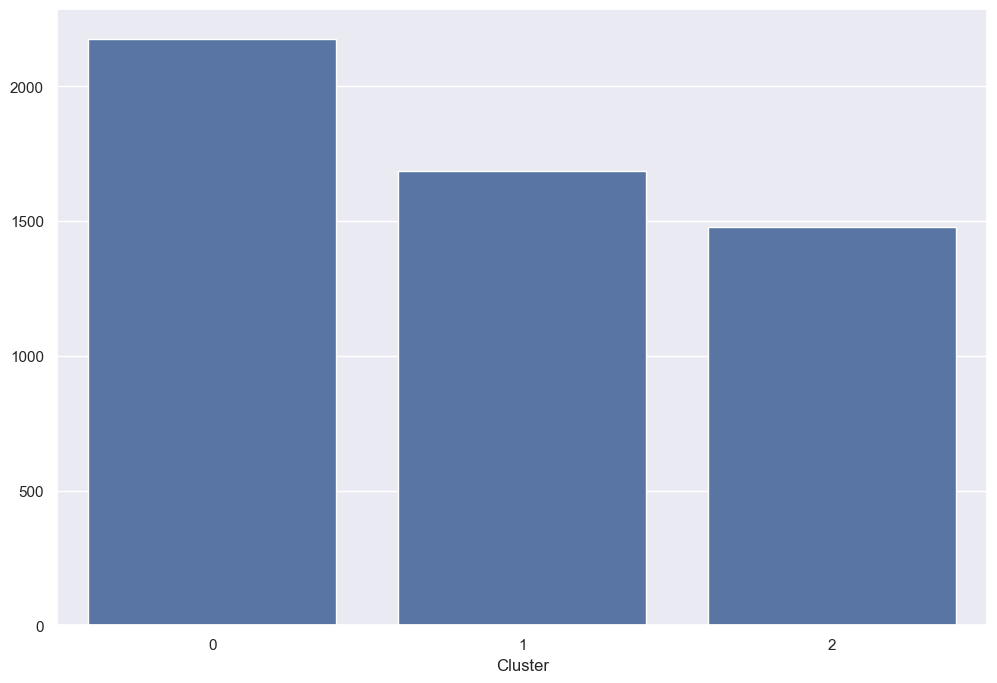

In [ ]:
# Revisar la cantidad de registros en los clústeres resultado
labels = res_kmeans2.labels_
df_bicis_model2_norm['Cluster'] = labels
cluster_distrib = df_bicis_model2_norm['Cluster'].value_counts()
fig=plt.figure(figsize=(12,8))
sns.barplot(x=cluster_distrib.index, y=cluster_distrib.values, color='b');


In [ ]:
# Revisar el número exacto de elementos por clúster y las variables utilizadas.
df_bicis_model2_norm.groupby('Cluster').count()

,Number_of_Casualties,Speed_limit,Number_of_Vehicles,Madrugada,Mañana,Noche,Tarde,Time
Cluster,,,,,,,,
0,2177,2177,2177,2177,2177,2177,2177,2177
1,1684,1684,1684,1684,1684,1684,1684,1684
2,1477,1477,1477,1477,1477,1477,1477,1477


In [ ]:
# Consultamos algunos de los registros en el clúster 0.
#Transformar el contenido de las columnas a arreglo
cols_number2 = df_bicis_model2_norm.to_numpy()
cols_number2[res_kmeans2.labels_ == 0, len(cols_transformed)-1]

array([1.0, 1.0, 1.0, ..., 1.0, 1.0, 1.0], dtype=object)

### 5.4.2  Graficar comportamiento en parejas de atributos de acuerdo a la agrupación

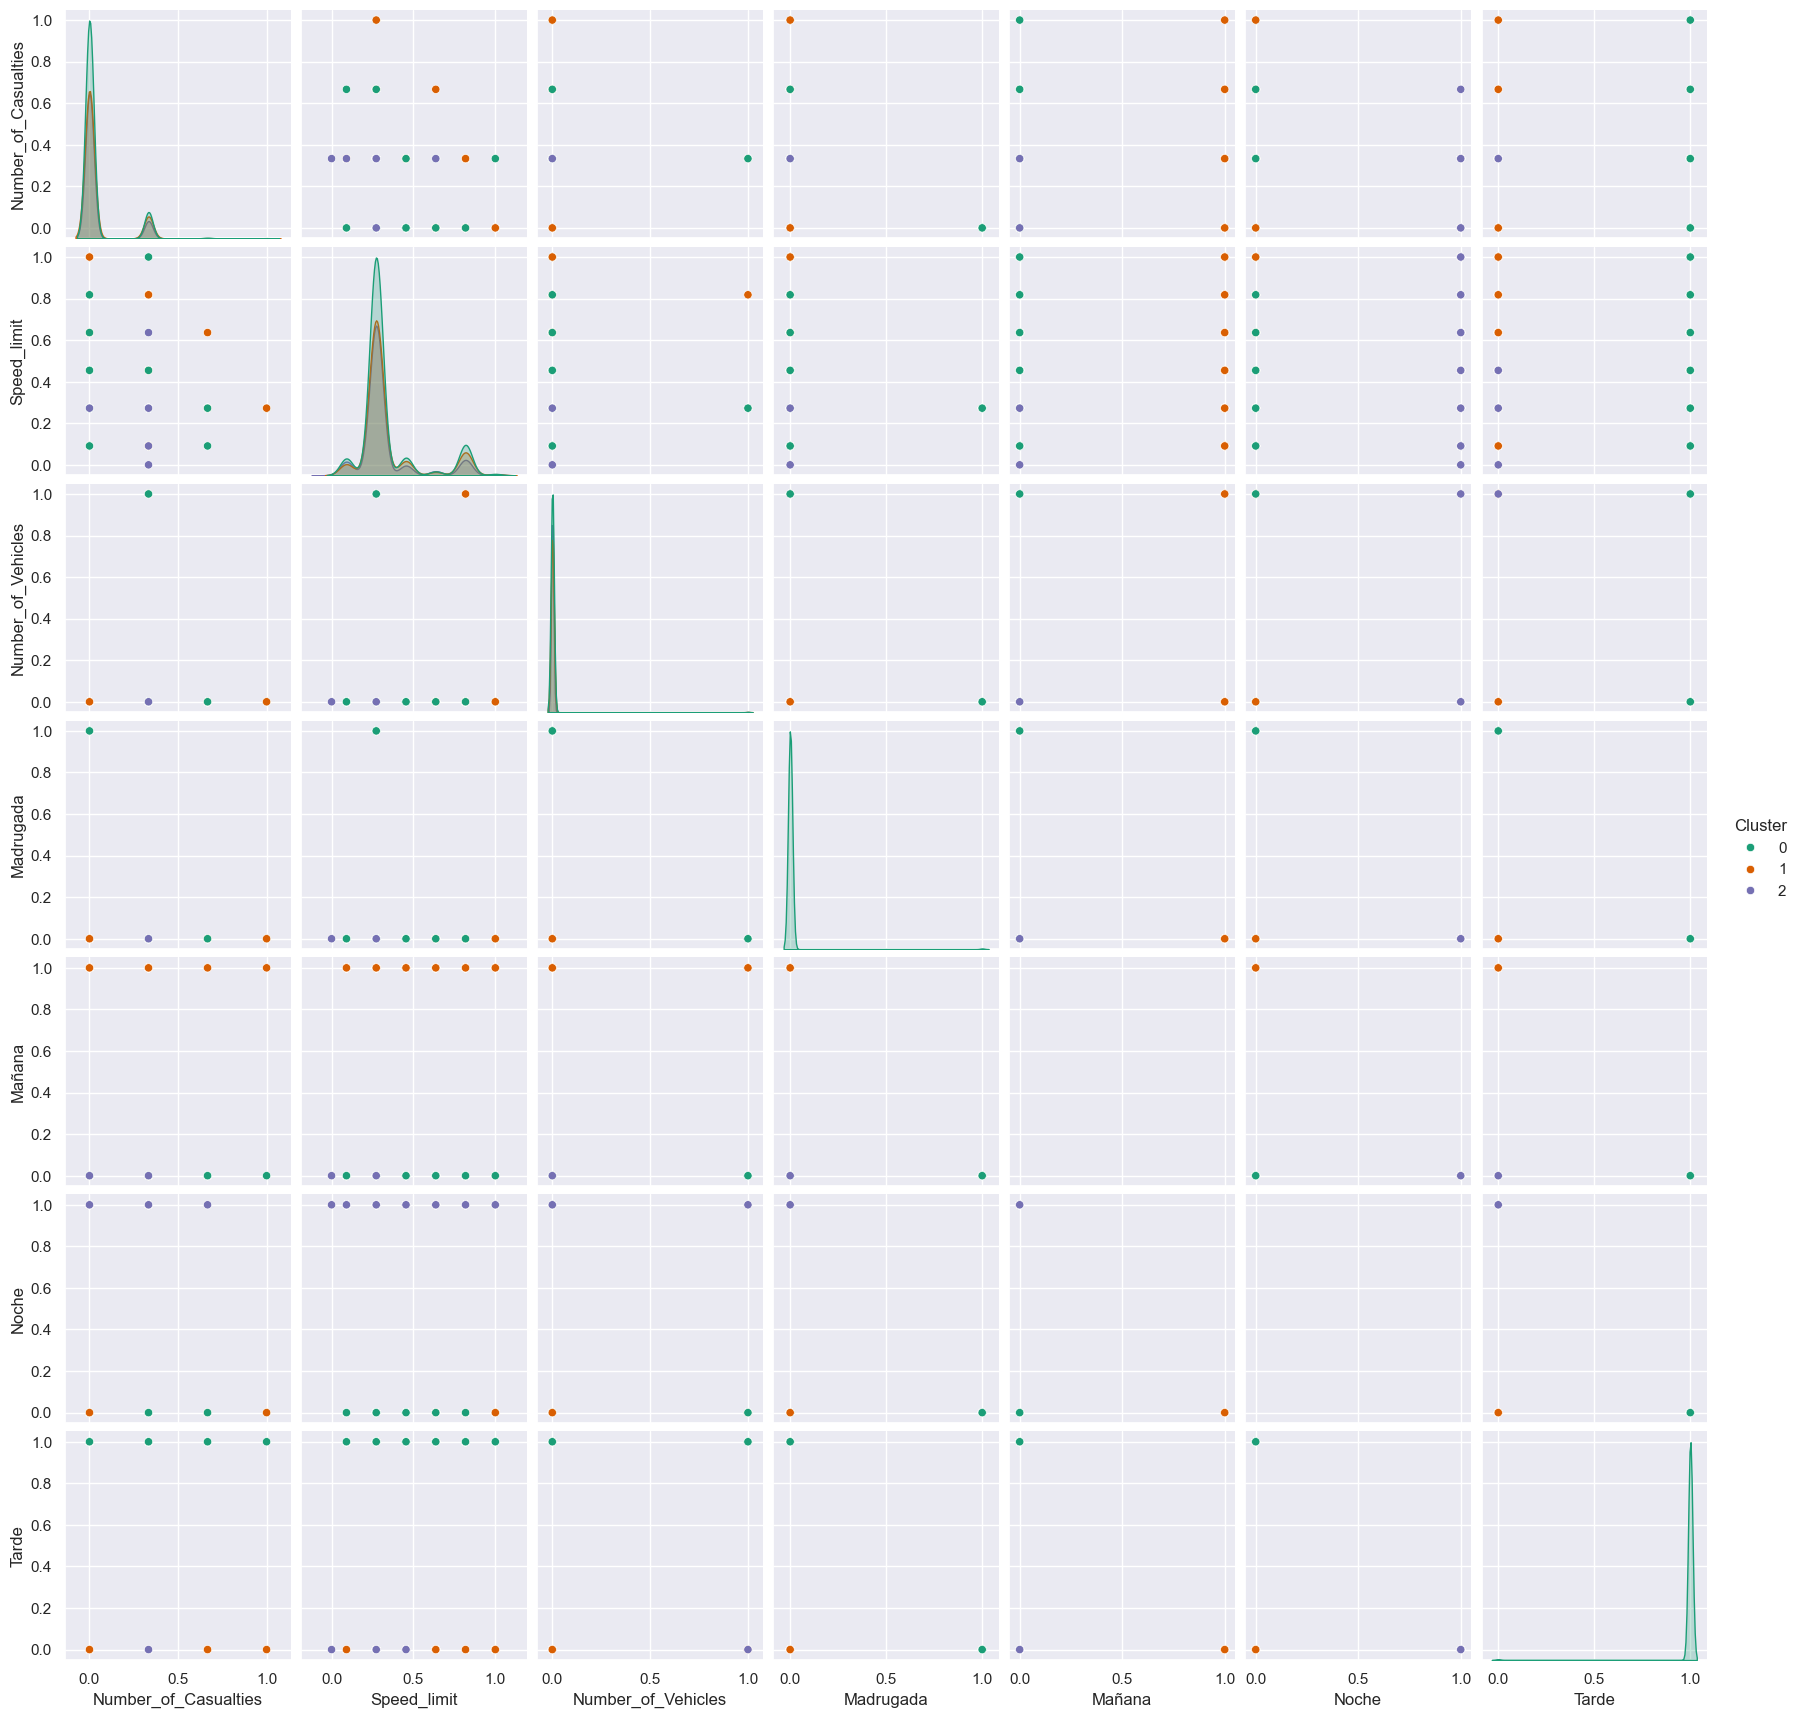

In [ ]:
# El análisis de la gráfica es más dificil ya que son más columnas. Podrías filtrar las columnas para entender mejor el gráfico
# Ajustar la paleta de colores para ver mejor
sns.pairplot(data=df_bicis_model2_norm, hue="Cluster", palette="Dark2")

### 5.4.3  Graficar dos atributos y ver la relaciónn con las agrupaciones

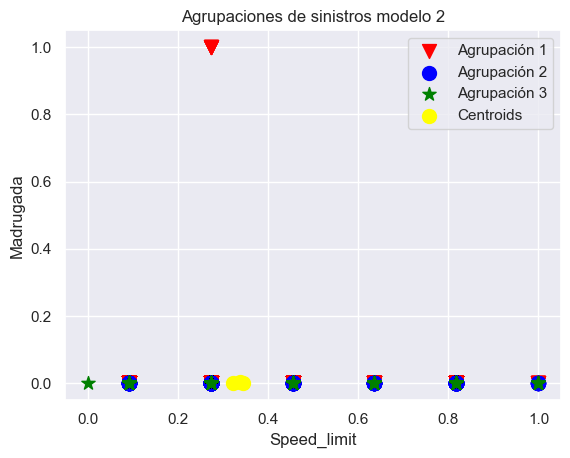

In [ ]:
# El análisis lo haremos por pareja de atributos, en este caso 
plt.scatter(cols_number2[res_kmeans2.labels_ == 0, 1], cols_number2[kmeans2.labels_ == 0, 3], s = 100, marker='v', c = 'red', label = 'Agrupación 1')
plt.scatter(cols_number2[res_kmeans2.labels_ == 1, 1], cols_number2[kmeans2.labels_ == 1, 3], s = 100, marker='o', c = 'blue', label = 'Agrupación 2')
plt.scatter(cols_number2[res_kmeans2.labels_ == 2, 1], cols_number2[kmeans2.labels_ == 2, 3], s = 100, marker='*', c = 'green', label = 'Agrupación 3')

plt.scatter(res_kmeans2.cluster_centers_[:, 1], res_kmeans2.cluster_centers_[:, 3], s = 100, c = 'yellow', label = 'Centroids')
plt.title('Agrupaciones de sinistros modelo 2')
plt.xlabel(cols_transformed[1])
plt.ylabel(cols_transformed[3])
plt.legend()
plt.show()


In [ ]:
# Revisemos los valores de los centroides de los clústeres generados
print('Centroides: [[',cols_transformed[0], ' ' , cols_transformed[1], ']]', res_kmeans2.cluster_centers_)

Centroides: [[ Number_of_Casualties   Speed_limit ]] [[3.78196295e-02 3.39040381e-01 1.37804318e-03 2.75608636e-03
  1.11022302e-16 2.77555756e-16 9.97243914e-01]
 [4.43388757e-02 3.45389765e-01 1.18764846e-03 0.00000000e+00
  1.00000000e+00 1.66533454e-16 1.05471187e-15]
 [3.58835477e-02 3.23628978e-01 6.77048070e-04 0.00000000e+00
  5.55111512e-17 1.00000000e+00 8.32667268e-16]]


### 5.4.4  Graficar los centroides de los grupos

In [ ]:
cols_transformed

['Number_of_Casualties',
 'Speed_limit',
 'Number_of_Vehicles',
 'Madrugada',
 'Mañana',
 'Noche',
 'Tarde']

In [ ]:
kmeans2.cluster_centers_.tolist()

[[0.03781962945950082,
  0.3390403808410239,
  0.0013780431786862611,
  0.0027560863573725296,
  1.1102230246251565e-16,
  2.7755575615628914e-16,
  0.9972439136426294],
 [0.044338875692794925,
  0.3453897646296696,
  0.0011876484560570052,
  0.0,
  1.000000000000001,
  1.6653345369377348e-16,
  1.0547118733938987e-15],
 [0.03588354773188895,
  0.3236289776574136,
  0.0006770480704129985,
  0.0,
  5.551115123125783e-17,
  0.9999999999999998,
  8.326672684688674e-16]]

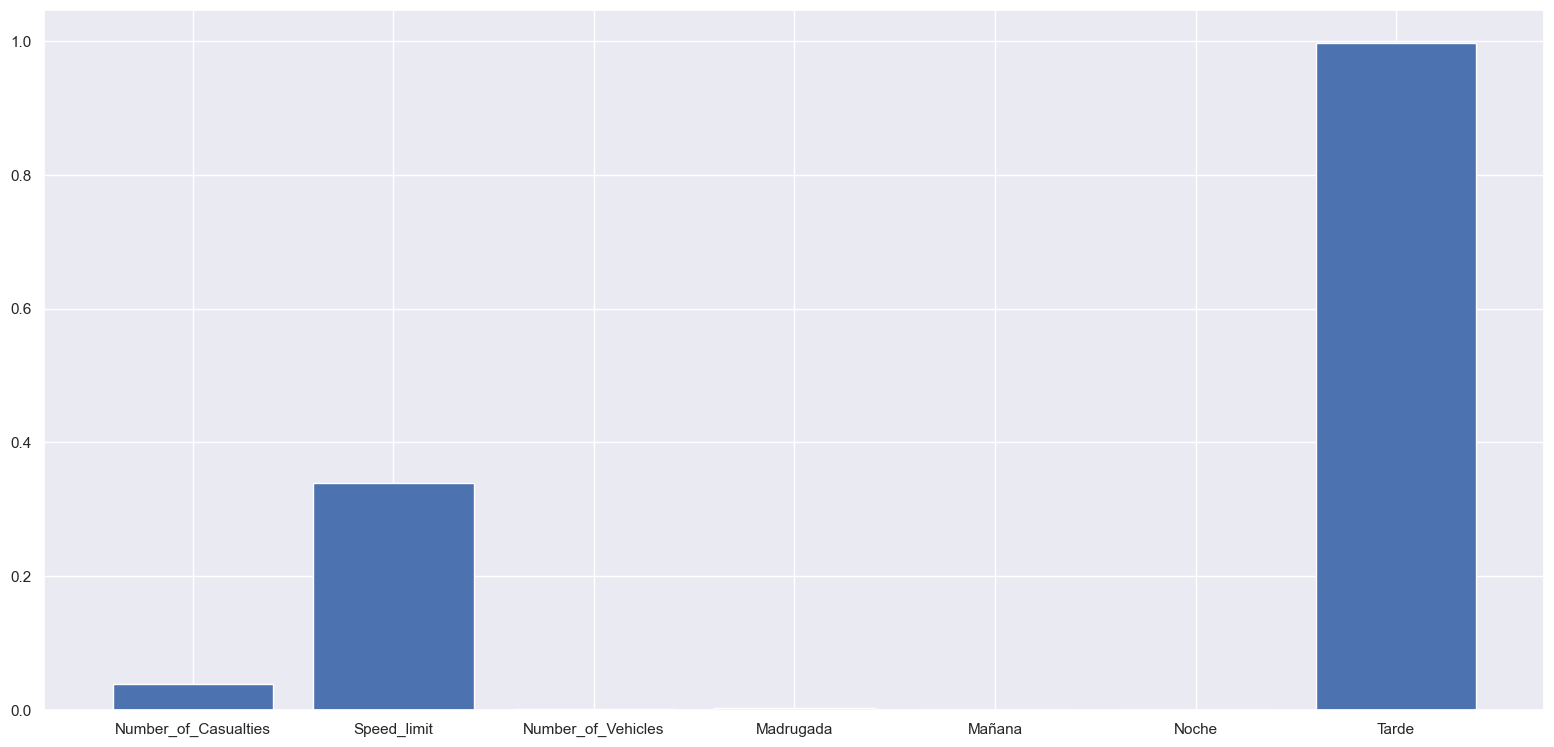

In [ ]:
#visualizar los centroides de un cluster. En el ejemplo, el grupo 0. 
# En este caso dado que los datos están normalizados los valores de algunas variables son muy pequeños y no se observan en la gráfica, por ejemplo: Num_vehicles
fig = plt.figure(figsize=(15, 7))
ax = fig.add_axes([0,0,1,1])
ax.bar(cols_transformed,res_kmeans2.cluster_centers_.tolist()[0])
plt.show()

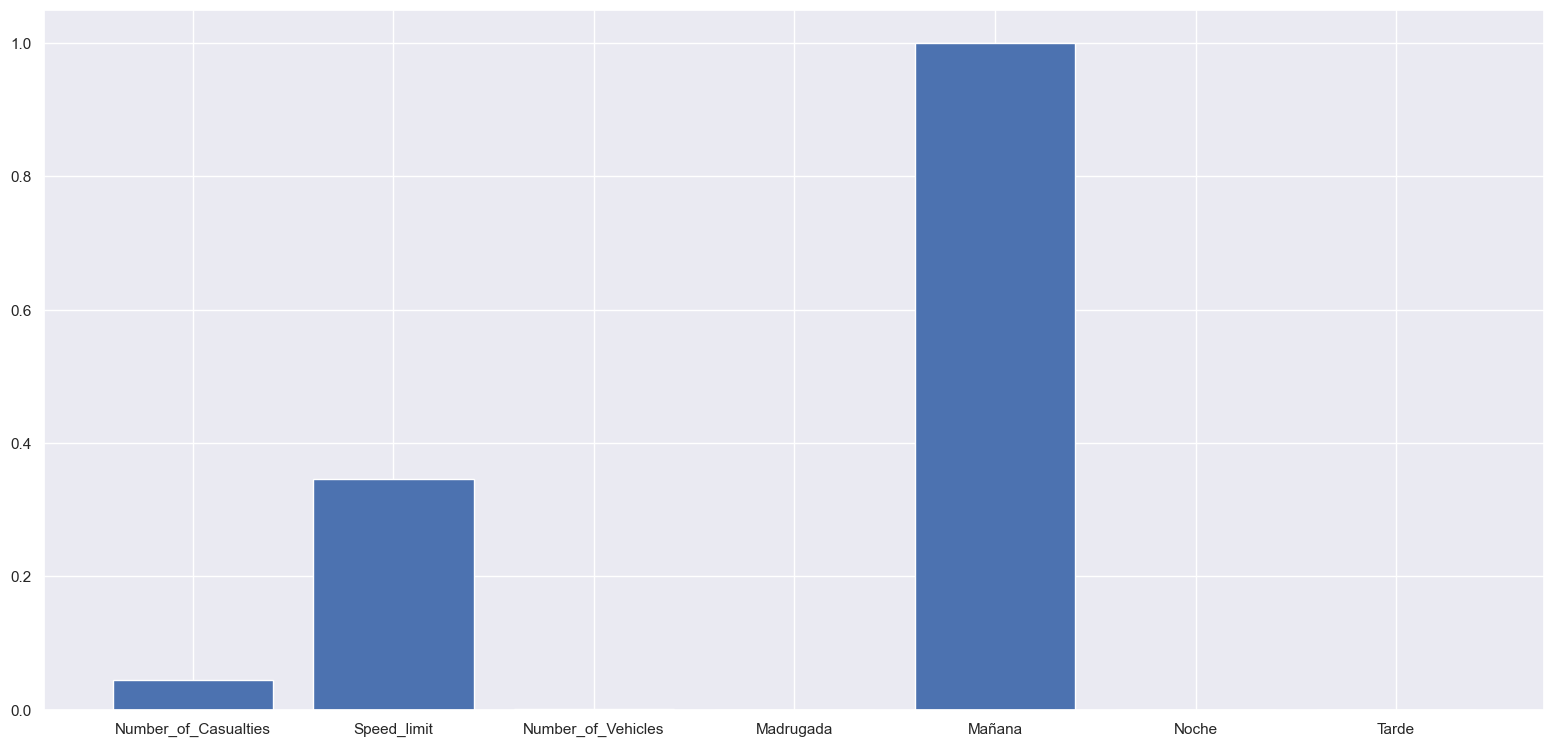

In [ ]:
#visualizar los centroides de un cluster. En el ejemplo, el grupo 1. 
fig = plt.figure(figsize=(15, 7))
ax = fig.add_axes([0,0,1,1])
ax.bar(cols_transformed,res_kmeans2.cluster_centers_.tolist()[1])
plt.show()

### 5.5. Evaluar la calidad de los clústeres obtenidos

[0 1 2]


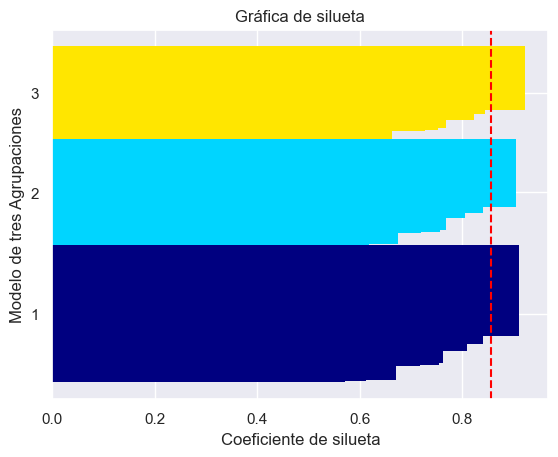

In [ ]:
# Esta función puede tardar varios minutos
# Un valor cercano a 1 es un indicador de un bueno modelo. Revisa la teoría para comprender mejor el concepto
plot_silhouette(data = df_bicis_model2_norm[cols_transformed], 
                labels = res_kmeans2.labels_, 
                ylabel = 'Modelo de tres Agrupaciones')

### 5.6 Análisis y conclusiones
<Span style="color:red"> ¿Qué pasó es un mejor modelo, comparado con el primero? ¿Qué nuevas mejoras podemos incorporar para generar un siguiente modelo?
</Span>

A nivel cuantitativo vemos que la silueta es similar a los resutlados de la primera iteración y vemos que hay registros 
más alejados de 1 en los diferentes grupos. Sin embargo, a diferencia de la primera silueta estos registros tienen siluetas superiores a 0.6 en comparación con 0.3 que se identificaron en la iteración 1.

A nivel cualitativo, podemos observar que si bien, los compartamientos en los grupos a nivel de "number of casualities" y "Speed_limit" siguen caracterizando los grupos dados, como información adicional se identifica que en el grupo 1, están los accidentes que ocurren en la tarde, mientras que en el grupo 2, los que ocurren en la mañana.
Con esto presente, se puede hablar con la secretaría de movilidad para que en horarios de tarde o mañana hagan las labores preventivas relacionadas con limite de velocidad correspondiente y en BiciAlpes se generen campañas para consciencitizar a los ciclistas y reducir los accidentes.
Adicionalmente, se puede completar la exploración, revisando estos grupos, a la luz de otras variables no incluídas en el algoritmo de k-means para describirlos mejor y usar los valores no transformados para entender mejor el significado.

## 6. Iteración3. Ejercicio: Nuevo modelo con mejoras a nivel de preparación de datos 

<Span style="color:red"> 
Te proponemos incluir nuevas variables y quitar los valores atípicos e incluir análisis con variables no utilizadas en el algoritmo de kmeans.
</Span>

In [ ]:
### 6.1 Identificar las variables a utilizar 
df_bicis_model3 = df_bicis.copy()

### 6.2 Preparación de datos


In [ ]:
# Eliminar datos desconocidos, Junction_Detail < 0	 tu puedes hacer algo similar para otras variables
# ¿Cuantas filas se borrarían?

aux_bicis=df_bicis_model3[df_bicis_model3['Junction_Detail'] < 0]


In [ ]:
aux_bicis.shape

(25, 15)

### 6.3 Construir el modelo

### 6.4. Visualizar el resultado

### 6.5. Evaluar la calidad de los clústeres obtenidos

### 6.6 Analizar y concluir
<Span style="color:red"> ¿Qué podemos decirle al negocio? ¿Las variables seleccionadas serán las apropiadas?
</Span>